# Forward and backward model selection

Greedy forward and backward selection over 37 candidate terms ($x^i v^j$ with $i, j \le 5$, `v|v|`, `u`) on the training levels. Each subset is scored with the common training score; the smallest subset within 10 % of the best score of each path is selected. The 1500 mg level is the test set.

## Imports


In [1]:
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "notebooks" / "pipeline").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Project root could not be located.")
    PROJECT_ROOT = PROJECT_ROOT.parent

COLORS = {"purple": "#5E3C99", "orange": "#D55E00", "green": "#009E73",
          "blue": "#0072B2", "brown": "#8C564B", "yellow": "#E69F00"}
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.size": 10,
    "mathtext.fontset": "stix",
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "lines.linewidth": 1.5,
    "axes.xmargin": 0.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "path.simplify": True,
    "agg.path.chunksize": 10000,
    "axes.prop_cycle": plt.cycler(color=list(COLORS.values())),
})


def slug(name):
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(name)).strip("_").lower()

## Shared protocol and paths


In [2]:
# Shared protocol: TEST_LEVEL_MG (both sweeps) is the test set; the other levels train.
# Predictions are made at the measured states; NRMSE = RMSE / std(measured).
LEVELS_MG = (500, 1000, 1500, 2000, 2500)
TEST_LEVEL_MG = 1500
TRAINING_LEVELS_MG = tuple(level for level in LEVELS_MG if level != TEST_LEVEL_MG)
ROLES = ("train", "test")
PROTOCOL_DESCRIPTION = (f"single train/test split: test level {TEST_LEVEL_MG} mg; "
                        f"training levels {TRAINING_LEVELS_MG} mg")
SWEEP_MIN_HZ, SWEEP_MAX_HZ = 50.0, 150.0
RESONANCE_BAND_HZ = (80.0, 110.0)
# Selection score on the training set: TOTAL_ERROR_WEIGHT * NRMSE
# + RESONANCE_ERROR_WEIGHT * resonance-band NRMSE. The smallest model within
# ACCEPTABLE_ERROR_INCREASE of the best score is selected.
TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT = 0.3, 0.7
ACCEPTABLE_ERROR_INCREASE = 0.1


def excitation_level_mg(name):
    return int(re.search(r"(\d+)mg", str(name)).group(1))


def sweep_direction(name):
    return "down" if "sweep_down" in str(name) else "up"


def sweep_frequency_hz(name, t):
    """Nominal frequency, assuming a linear sweep."""
    fraction = (t - t[0]) / (t[-1] - t[0])
    if sweep_direction(name) == "down":
        return SWEEP_MAX_HZ - fraction * (SWEEP_MAX_HZ - SWEEP_MIN_HZ)
    return SWEEP_MIN_HZ + fraction * (SWEEP_MAX_HZ - SWEEP_MIN_HZ)


def resonance_band_mask(name, t):
    """Samples whose nominal sweep frequency lies in the resonance band."""
    frequency = sweep_frequency_hz(name, t)
    return (frequency >= RESONANCE_BAND_HZ[0]) & (frequency <= RESONANCE_BAND_HZ[1])


def signal_role(name):
    """Split role of an experiment: 'test' at the test level, 'train' otherwise."""
    return "test" if excitation_level_mg(name) == TEST_LEVEL_MG else "train"


def check_signals(signals, require_all_levels=True):
    names = [s["name"] for s in signals]
    if len(set(names)) != len(names):
        raise ValueError("Signal names must be unique.")
    found = {}
    for signal in signals:
        level = excitation_level_mg(signal["name"])
        if level not in LEVELS_MG:
            raise ValueError(f"Unknown excitation level: {signal['name']}")
        found.setdefault(level, []).append(sweep_direction(signal["name"]))
        arrays = [np.asarray(signal[k], dtype=float).reshape(-1) for k in ("t", "x", "v", "u", "v_dot")]
        if len({len(a) for a in arrays}) != 1 or len(arrays[0]) < 2:
            raise ValueError(f"Mismatched array lengths: {signal['name']}")
        if not all(np.isfinite(a).all() for a in arrays):
            raise ValueError(f"Nonfinite data: {signal['name']}")
        if np.any(np.diff(arrays[0]) <= 0):
            raise ValueError(f"Time must increase: {signal['name']}")
    for level in (LEVELS_MG if require_all_levels else found):
        if sorted(found.get(level, [])) != ["down", "up"]:
            raise ValueError(f"Level {level} mg needs exactly one upward and one downward sweep.")
    return sorted(signals, key=lambda s: (excitation_level_mg(s["name"]), s["name"]))


def split_signals(signals):
    """Single train/test split by excitation level."""
    signals = check_signals(signals)
    return {"test_level_mg": TEST_LEVEL_MG, "fit_levels_mg": TRAINING_LEVELS_MG,
            "fit": [s for s in signals if signal_role(s["name"]) == "train"],
            "test": [s for s in signals if signal_role(s["name"]) == "test"]}


def split_table(split):
    rows = []
    for role, key, levels in (("train", "fit", split["fit_levels_mg"]),
                              ("test", "test", (split["test_level_mg"],))):
        rows.append({"role": role, "levels_mg": tuple(levels), "experiments": len(split[key]),
                     "samples": sum(len(s["t"]) for s in split[key])})
    return pd.DataFrame(rows)


def scores(measured, predicted, resonance_mask, weights):
    residual = measured - predicted
    rmse = np.sqrt(np.mean(residual ** 2))
    nrmse = rmse / np.std(measured)
    r2 = 1.0 - np.sum(residual ** 2) / np.sum((measured - np.mean(measured)) ** 2)
    resonance = (np.sqrt(np.mean(residual[resonance_mask] ** 2))
                 / np.std(measured[resonance_mask]))
    return {"total_RMSE": rmse, "total_NRMSE": nrmse, "total_R2": r2,
            "resonance_NRMSE": resonance,
            "weighted_score": weights[0] * nrmse + weights[1] * resonance}


def build_series(signals):
    series = {}
    for signal in check_signals(signals, require_all_levels=False):
        name = signal["name"]
        t, x, v, u, measured = (np.asarray(signal[k], dtype=float).reshape(-1)
                                for k in ("t", "x", "v", "u", "v_dot"))
        series[name] = {
            "level_mg": excitation_level_mg(name), "sweep": sweep_direction(name),
            "role": signal_role(name),
            "time": t - t[0], "x": x, "v": v, "input": u,
            "experimental_acceleration": measured,
            "instantaneous_frequency_hz": sweep_frequency_hz(name, t),
            "resonance_mask": resonance_band_mask(name, t),
            "model_predictions": {},
        }
    return series


def add_predictions(series, model_functions, names=None):
    """Store each model's predictions under the role of each experiment (or only `names`)."""
    for name, record in series.items():
        if names is not None and name not in names:
            continue
        x, v, u = record["x"], record["v"], record["input"]
        for model_name, function in model_functions.items():
            predicted = np.broadcast_to(np.asarray(function(x, v, u), dtype=float),
                                        record["experimental_acceleration"].shape).astype(float)
            if not np.isfinite(predicted).all():
                raise ValueError(f"Nonfinite prediction: {model_name} on {name}")
            record["model_predictions"].setdefault(model_name, {})[record["role"]] = predicted
    return series


def summarize_models(series, weights=(TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT)):
    """Metric tables per signal, per level and per role (train/test, pooled)."""
    per_signal, models = [], []
    for name, record in series.items():
        for model, roles in record["model_predictions"].items():
            if model not in models:
                models.append(model)
            for role, predicted in roles.items():
                per_signal.append({
                    "signal": name, "level_mg": record["level_mg"], "sweep": record["sweep"],
                    "model": model, "role": role,
                    **scores(record["experimental_acceleration"], predicted,
                             record["resonance_mask"], weights)})
    per_level, aggregate = [], []
    for model in models:
        names = [n for n, r in series.items() if model in r["model_predictions"]]

        def pooled(group):
            measured = np.concatenate([series[n]["experimental_acceleration"] for n in group])
            mask = np.concatenate([series[n]["resonance_mask"] for n in group])
            predicted = np.concatenate([series[n]["model_predictions"][model][series[n]["role"]]
                                        for n in group])
            return {"signals": len(group), "samples": len(measured),
                    **scores(measured, predicted, mask, weights)}

        for level in sorted({series[n]["level_mg"] for n in names}):
            group = [n for n in names if series[n]["level_mg"] == level]
            per_level.append({"level_mg": level, "role": series[group[0]]["role"],
                              "model": model, **pooled(group)})
        for role in ROLES:
            group = [n for n in names if series[n]["role"] == role]
            if group:
                aggregate.append({"model": model, "role": role,
                                  "levels_mg": tuple(sorted({series[n]["level_mg"] for n in group})),
                                  **pooled(group)})
    return (pd.DataFrame(per_signal), pd.DataFrame(per_level), pd.DataFrame(aggregate))


def regression_block(library, target, resonance_mask):
    """Library, target and resonance mask of one experiment (all samples)."""
    library = np.asarray(library, dtype=float)
    target = np.asarray(target, dtype=float).reshape(-1)
    resonance_mask = np.asarray(resonance_mask, dtype=bool).reshape(-1)
    if library.shape[0] != len(target) or len(resonance_mask) != len(target):
        raise ValueError("Library, target and resonance mask must have the same number of samples.")
    return {"Theta": library, "y": target, "resonance_mask": resonance_mask, "samples": len(target)}


def coefficient_scores(theta, blocks):
    """Pooled NRMSE, resonance-band NRMSE and selection score of a coefficient vector."""
    residual = np.concatenate([b["y"] - b["Theta"] @ theta for b in blocks])
    measured = np.concatenate([b["y"] for b in blocks])
    mask = np.concatenate([b["resonance_mask"] for b in blocks])
    total = np.sqrt(np.mean(residual ** 2)) / np.std(measured)
    resonance = np.sqrt(np.mean(residual[mask] ** 2)) / np.std(measured[mask])
    return {"nrmse": total, "resonance_nrmse": resonance,
            "score": TOTAL_ERROR_WEIGHT * total + RESONANCE_ERROR_WEIGHT * resonance}


def within_tolerance(results, score_column="training_score"):
    """Rows whose score is within ACCEPTABLE_ERROR_INCREASE of the best finite score."""
    finite = results[np.isfinite(results[score_column])]
    limit = finite[score_column].min() * (1.0 + ACCEPTABLE_ERROR_INCREASE) + 1e-14
    return finite[finite[score_column] <= limit]


In [3]:
# Line styles: solid = test, dashed = train.
ROLE_STYLES = {"train": "--", "test": "-"}
ROLE_LABELS = {"train": "Train", "test": "Test"}


def plot_diagnostics(series, folder):
    scales = {}
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    for name, record in series.items():
        label = f"{record['level_mg']} mg, sweep {record['sweep']}"
        time, x, v, u = record["time"], record["x"], record["v"], record["input"]
        measured, mask = record["experimental_acceleration"], record["resonance_mask"]
        predictions = [(model, role, predicted)
                       for model, roles in record["model_predictions"].items()
                       for role, predicted in roles.items()]
        tip = measured + u
        x_scale, v_scale, tip_scale = (max(np.max(np.abs(a)), np.finfo(float).eps)
                                       for a in (x, v, tip))
        scales[name] = {"x_scale": x_scale, "v_scale": v_scale, "a_tip_scale": tip_scale,
                        "level_mg": record["level_mg"], "comparison_points": len(x),
                        "normalization": "maximum absolute experimental value"}

        for window, tag in [(slice(None), "time"), (mask, "resonance")]:
            fig, ax = plt.subplots()
            ax.plot(time[window], measured[window], color="k", lw=1.0,
                    label=f"Experimental - {label}")
            for model, role, predicted in predictions:
                ax.plot(time[window], predicted[window], ROLE_STYLES[role], lw=0.4,
                        alpha=0.55, label=f"{model} ({ROLE_LABELS[role]})")
            ax.set_xlabel("Time [s]")
            ax.set_ylabel("Relative acceleration [m/s$^2$]")
            ax.legend(loc="upper right")
            fig.savefig(folder / f"one_step_{tag}_{slug(name)}.pdf", format="pdf")
            plt.show()
            plt.close(fig)

        fig, ax = plt.subplots()
        for model, role, predicted in predictions:
            ax.scatter(measured, predicted, s=2, alpha=0.2, rasterized=True,
                       label=f"{model} ({ROLE_LABELS[role]})")
        limits = [float(measured.min()), float(measured.max())]
        ax.plot(limits, limits, "k--", lw=1.0, label=f"Ideal - {label}")
        ax.set_xlabel("Measured $a_{\\mathrm{rel}}$ [m/s$^2$]")
        ax.set_ylabel("Predicted $a_{\\mathrm{rel}}$ [m/s$^2$]")
        ax.legend(loc="upper left")
        fig.savefig(folder / f"one_step_parity_{slug(name)}.pdf", format="pdf")
        plt.show()
        plt.close(fig)

        cuts = [(v, v_scale, np.abs(x / x_scale) <= 1e-3, "velocity, $v^*$", "velocity"),
                (x, x_scale, np.abs(v / v_scale) <= 1e-3, "displacement, $x^*$", "displacement")]
        for axis, scale, cut, axis_label, tag in cuts:
            fig, ax = plt.subplots()
            ax.scatter(axis[cut] / scale, tip[cut] / tip_scale, s=9, color="k",
                       rasterized=True, label=f"Experimental - {label}")
            for model, role, predicted in predictions:
                ax.scatter(axis[cut] / scale, (predicted + u)[cut] / tip_scale, s=7,
                           alpha=0.5, rasterized=True, label=f"{model} ({ROLE_LABELS[role]})")
            ax.set_xlabel(f"Dimensionless {axis_label}")
            ax.set_ylabel("Dimensionless tip acceleration, $a_{\\mathrm{tip}}^*$")
            ax.legend(loc="upper left")
            fig.savefig(folder / f"dimensionless_{tag}_{slug(name)}.pdf", format="pdf")
            plt.show()
            plt.close(fig)
    return scales


def plot_level_metrics(per_level, metric, ylabel, filename):
    table = per_level.assign(label=per_level["model"] + " (" + per_level["role"].map(ROLE_LABELS) + ")")
    table = table.pivot(index="level_mg", columns="label", values=metric)
    fig, ax = plt.subplots()
    table.plot.bar(ax=ax)
    ax.set(xlabel="Excitation level [mg]", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=7)
    fig.savefig(filename)
    plt.show()
    plt.close(fig)
    return table

In [4]:
DIMENSIONLESS_ZERO_TOLERANCE = 0.001
RESULTS_DIR = PROJECT_ROOT / "results"
PREPARED_FILE = RESULTS_DIR / "prepared_signals.pkl"
FIGURES_DIR = (PROJECT_ROOT / "figures" / "pipeline" / "3_least_squares_selection"
               / "forward_backward_one_step")
if not PREPARED_FILE.exists():
    raise FileNotFoundError("results/prepared_signals.pkl was not found. Run notebook 2 first.")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load trajectories


In [5]:
with PREPARED_FILE.open("rb") as file:
    prepared_data = pickle.load(file)
spectral_signals = prepared_data["spectral_signals"]
print("Number of spectral trajectories:", len(spectral_signals))
for index, signal in enumerate(spectral_signals):
    print(index, "-", signal["name"])


Number of spectral trajectories: 10
0 - relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_down
1 - relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_up
2 - relative_acceleration_000mA_1500mg_50-150_Hz_sweep-up-down__sweep_down
3 - relative_acceleration_000mA_1500mg_50-150_Hz_sweep-up-down__sweep_up
4 - relative_acceleration_000mA_2000mg_50-150_Hz_sweep-up-down__sweep_down
5 - relative_acceleration_000mA_2000mg_50-150_Hz_sweep-up-down__sweep_up
6 - relative_acceleration_000mA_2500mg_50-150_Hz_sweep-up-down__sweep_down
7 - relative_acceleration_000mA_2500mg_50-150_Hz_sweep-up-down__sweep_up
8 - relative_acceleration_000mA_500mg_50-150_Hz_sweep-up-down__sweep_down
9 - relative_acceleration_000mA_500mg_50-150_Hz_sweep-up-down__sweep_up


## Train/test split

In [6]:
all_signals = check_signals(spectral_signals)
split = split_signals(all_signals)
split_summary = split_table(split)
display(split_summary)

,role,levels_mg,experiments,samples
0,train,"(500, 1000, 2000, 2500)",8,3211138
1,test,"(1500,)",2,802753


## Candidate library and regression rows of every experiment

In [7]:
MAX_X_POWER = 5
MAX_V_POWER = 5
POLYNOMIAL_POWERS = sorted(
    ((i, j) for i in range(MAX_X_POWER + 1) for j in range(MAX_V_POWER + 1) if i + j > 0),
    key=lambda powers: (sum(powers), -powers[0]),
)


def monomial_name(i, j):
    return "*".join(
        (variable if power == 1 else f"{variable}^{power}"
         for variable, power in (("x", i), ("v", j)) if power)
    )


TERM_NAMES = [monomial_name(i, j) for i, j in POLYNOMIAL_POWERS] + ["v|v|", "u"]
TERM_UNITS = [f"m^({1 - i - j})*s^({j - 2})" for i, j in POLYNOMIAL_POWERS] + ["1/m", "1"]


def build_library(x, v, u):
    x, v, u = np.broadcast_arrays(
        np.asarray(x, dtype=float), np.asarray(v, dtype=float), np.asarray(u, dtype=float)
    )
    return np.stack([x**i * v**j for i, j in POLYNOMIAL_POWERS] + [v * np.abs(v), u], axis=-1)


def trajectory_arrays(signal):
    return tuple(np.asarray(signal[k], dtype=float).reshape(-1) for k in ("t", "x", "v", "u", "v_dot"))


def model_acceleration(x, v, u, theta):
    return build_library(x, v, u) @ theta


# Regression rows of every experiment (all samples).
blocks = {}
usage_rows = []
for signal in all_signals:
    t, x, v, u, target = trajectory_arrays(signal)
    blocks[signal["name"]] = regression_block(build_library(x, v, u), target,
                                              resonance_band_mask(signal["name"], t))
    usage_rows.append({"level_mg": excitation_level_mg(signal["name"]),
                       "sweep": sweep_direction(signal["name"]), "role": signal_role(signal["name"]),
                       "samples": len(target), "name": signal["name"]})
usage_table = pd.DataFrame(usage_rows)
display(usage_table)
print("Library:", TERM_NAMES)
print(f"Experiments: {len(blocks)}; samples: {usage_table['samples'].sum():,} (all used, no compression)")

,level_mg,sweep,role,samples,name
0,500,down,train,401408,relative_acceleration_000mA_500mg_50-150_Hz_sw...
1,500,up,train,401408,relative_acceleration_000mA_500mg_50-150_Hz_sw...
2,1000,down,train,401377,relative_acceleration_000mA_1000mg_50-150_Hz_s...
3,1000,up,train,401376,relative_acceleration_000mA_1000mg_50-150_Hz_s...
4,1500,down,test,401377,relative_acceleration_000mA_1500mg_50-150_Hz_s...
5,1500,up,test,401376,relative_acceleration_000mA_1500mg_50-150_Hz_s...
6,2000,down,train,401408,relative_acceleration_000mA_2000mg_50-150_Hz_s...
7,2000,up,train,401408,relative_acceleration_000mA_2000mg_50-150_Hz_s...
8,2500,down,train,401377,relative_acceleration_000mA_2500mg_50-150_Hz_s...
9,2500,up,train,401376,relative_acceleration_000mA_2500mg_50-150_Hz_s...


Library: ['x', 'v', 'x^2', 'x*v', 'v^2', 'x^3', 'x^2*v', 'x*v^2', 'v^3', 'x^4', 'x^3*v', 'x^2*v^2', 'x*v^3', 'v^4', 'x^5', 'x^4*v', 'x^3*v^2', 'x^2*v^3', 'x*v^4', 'v^5', 'x^5*v', 'x^4*v^2', 'x^3*v^3', 'x^2*v^4', 'x*v^5', 'x^5*v^2', 'x^4*v^3', 'x^3*v^4', 'x^2*v^5', 'x^5*v^3', 'x^4*v^4', 'x^3*v^5', 'x^5*v^4', 'x^4*v^5', 'x^5*v^5', 'v|v|', 'u']
Experiments: 10; samples: 4,013,891 (all used, no compression)


## Selection on the training levels

In [8]:
def prepare_fit(experiments):
    matrix = np.vstack([blocks[e["name"]]["Theta"] for e in experiments])
    target = np.concatenate([blocks[e["name"]]["y"] for e in experiments])
    scale = np.linalg.norm(matrix, axis=0)
    scale[scale == 0] = 1.0
    matrix /= scale  # in place, to avoid copying the training matrix
    return (matrix, target, scale)


def fit_compact_subset(fit, indices):
    matrix, target, scale = fit
    theta = np.zeros(len(TERM_NAMES))
    if indices:
        values, _, rank, _ = np.linalg.lstsq(matrix[:, list(indices)], target, rcond=None)
        if rank < len(indices):
            raise ValueError("Rank-deficient candidate library on the training levels.")
        theta[list(indices)] = values / scale[list(indices)]
    return theta


def run_selection(fit_signals, label):
    training_fit = prepare_fit(fit_signals)
    training_blocks = [blocks[s["name"]] for s in fit_signals]
    cache = {}

    def score_subset(indices):
        indices = tuple(sorted(indices))
        if indices not in cache:
            theta = fit_compact_subset(training_fit, indices)
            fit_scores = coefficient_scores(theta, training_blocks)
            cache[indices] = {"indices": indices, "coefficients": theta,
                              "training_score": float(fit_scores["score"]),
                              "training_nrmse": float(fit_scores["nrmse"]),
                              "training_resonance_nrmse": float(fit_scores["resonance_nrmse"])}
        return cache[indices]

    def selection_path(direction):
        current = score_subset(() if direction == "forward" else range(len(TERM_NAMES)))
        path, changed_terms = [current], ["initial"]
        for _ in range(len(TERM_NAMES)):
            selected = set(current["indices"])
            choices = [j for j in range(len(TERM_NAMES))
                       if (j not in selected if direction == "forward" else j in selected)]
            candidates = [(score_subset(selected | {j} if direction == "forward" else selected - {j}), j)
                          for j in choices]
            current, changed = min(candidates, key=lambda item: item[0]["training_score"])
            path.append(current)
            changed_terms.append(TERM_NAMES[changed])
        return (path, changed_terms)

    def choose_sparse_model(path, changed_terms):
        path_best = min(r["training_score"] for r in path)
        path_limit = path_best * (1 + ACCEPTABLE_ERROR_INCREASE) + 1e-14
        eligible = [r for r in path if r["training_score"] <= path_limit]
        chosen = min(eligible, key=lambda r: (len(r["indices"]), r["training_score"]))
        result = {**chosen, "training_score_limit": path_limit, "best_path_training_score": path_best,
                  "terms": [TERM_NAMES[j] for j in chosen["indices"]]}
        history = pd.DataFrame(
            [{"step": step, "changed_term": term, "n_terms": len(r["indices"]),
              "terms": ", ".join(TERM_NAMES[j] for j in r["indices"]),
              "training_score": r["training_score"], "training_nrmse": r["training_nrmse"],
              "training_resonance_nrmse": r["training_resonance_nrmse"],
              "within_tolerance": r["training_score"] <= path_limit,
              "selected": r["indices"] == chosen["indices"]}
             for step, (r, term) in enumerate(zip(path, changed_terms))]
        )
        return (result, history)

    run = {"label": label, "fit_levels_mg": tuple(sorted({excitation_level_mg(s["name"]) for s in fit_signals})),
           "training_samples": len(training_fit[1])}
    for direction in ("forward", "backward"):
        path, changes = selection_path(direction)
        run[direction], run[f"{direction}_history"] = choose_sparse_model(path, changes)
    run["best_training_score"] = min(run["forward"]["best_path_training_score"],
                                     run["backward"]["best_path_training_score"])
    return run


selection_run = run_selection(split["fit"], f"training levels {split['fit_levels_mg']} mg")
print("Selection on the training levels: "
      + "; ".join(f"{d} {len(selection_run[d]['indices'])} terms "
                  f"(training score {selection_run[d]['training_score']:.6f})"
                  for d in ("forward", "backward")))


Selection on the training levels: forward 10 terms (training score 0.016421); backward 10 terms (training score 0.016074)


### Selected models


In [9]:
selection_summary = pd.DataFrame(
    [{"run": selection_run["label"], "direction": direction, "n_terms": len(selection_run[direction]["indices"]),
      "terms": ", ".join(selection_run[direction]["terms"]),
      "training_score": selection_run[direction]["training_score"],
      "training_score_limit": selection_run[direction]["training_score_limit"]}
     for direction in ("forward", "backward")]
)
display(selection_summary)
print(f"Selected equations (training levels {split['fit_levels_mg']} mg):")
for direction in ("forward", "backward"):
    result = selection_run[direction]
    print(f"{direction}: {len(result['indices'])} terms; training score = {result['training_score']:.6f}")
    print("a_rel = " + " + ".join(f"({result['coefficients'][j]:+.8e}) {TERM_NAMES[j]}" for j in result["indices"]))
display(selection_run["forward_history"])
display(selection_run["backward_history"])
selection_models = {direction: selection_run[direction]["coefficients"] for direction in ("forward", "backward")}
selection_coefficient_table = pd.DataFrame({"term": TERM_NAMES, "unit": TERM_UNITS, **selection_models})
display(selection_coefficient_table)

,run,direction,n_terms,terms,training_score,training_score_limit
0,"training levels (500, 1000, 2000, 2500) mg",forward,10,"x, v, x^2, v^2, x^3, x*v^2, v^4, x^5, x^3*v^4, u",0.016421,0.016535
1,"training levels (500, 1000, 2000, 2500) mg",backward,10,"x, v, x^2, v^2, x^3, x*v^2, x^5, x^3*v^2, v|v|, u",0.016074,0.016535


Selected equations (training levels (500, 1000, 2000, 2500) mg):
forward: 10 terms; training score = 0.016421
a_rel = (-3.61124524e+05) x + (-3.14259404e+01) v + (+1.41827405e+07) x^2 + (-3.31857053e+01) v^2 + (+4.82808171e+10) x^3 + (+7.82978774e+04) x*v^2 + (-3.05723502e+01) v^4 + (-2.07875080e+16) x^5 + (-3.94066781e+11) x^3*v^4 + (-1.06037296e+00) u
backward: 10 terms; training score = 0.016074
a_rel = (-3.61306593e+05) x + (-2.55530346e+01) v + (+1.45685126e+07) x^2 + (-4.20141218e+01) v^2 + (+5.20862952e+10) x^3 + (+7.31997810e+04) x*v^2 + (-2.20167904e+16) x^5 + (-8.91886498e+10) x^3*v^2 + (-1.61850364e+01) v|v| + (-1.06110752e+00) u


,step,changed_term,n_terms,terms,training_score,training_nrmse,training_resonance_nrmse,within_tolerance,selected
0,0,initial,0,,1.000000,1.000000,1.000000,False,False
1,1,x,1,x,0.135166,0.192510,0.110590,False,False
2,2,u,2,"x, u",0.069756,0.069747,0.069760,False,False
3,3,v,3,"x, v, u",0.047562,0.048280,0.047254,False,False
4,4,v^4,4,"x, v, v^4, u",0.041257,0.042547,0.040704,False,False
5,5,x^2,5,"x, v, x^2, v^4, u",0.033044,0.035375,0.032044,False,False
6,6,x^3,6,"x, v, x^2, x^3, v^4, u",0.023730,0.024708,0.023310,False,False
7,7,x^5,7,"x, v, x^2, x^3, v^4, x^5, u",0.020956,0.021381,0.020774,False,False
8,8,v^2,8,"x, v, x^2, v^2, x^3, v^4, x^5, u",0.019295,0.019903,0.019035,False,False
9,9,x*v^2,9,"x, v, x^2, v^2, x^3, x*v^2, v^4, x^5, u",0.017395,0.018067,0.017107,False,False


,step,changed_term,n_terms,terms,training_score,training_nrmse,training_resonance_nrmse,within_tolerance,selected
0,0,initial,37,"x, v, x^2, x*v, v^2, x^3, x^2*v, x*v^2, v^3, x...",0.015032,0.015273,0.014928,True,False
1,1,x^5*v^5,36,"x, v, x^2, x*v, v^2, x^3, x^2*v, x*v^2, v^3, x...",0.015032,0.015273,0.014928,True,False
2,2,x^4*v^5,35,"x, v, x^2, x*v, v^2, x^3, x^2*v, x*v^2, v^3, x...",0.015032,0.015273,0.014928,True,False
3,3,x^4*v^4,34,"x, v, x^2, x*v, v^2, x^3, x^2*v, x*v^2, v^3, x...",0.015032,0.015273,0.014928,True,False
4,4,x*v,33,"x, v, x^2, v^2, x^3, x^2*v, x*v^2, v^3, x^4, x...",0.015032,0.015273,0.014928,True,False
5,5,x^2*v^2,32,"x, v, x^2, v^2, x^3, x^2*v, x*v^2, v^3, x^4, x...",0.015032,0.015273,0.014929,True,False
6,6,x^5*v^3,31,"x, v, x^2, v^2, x^3, x^2*v, x*v^2, v^3, x^4, x...",0.015032,0.015274,0.014929,True,False
7,7,x^3*v^5,30,"x, v, x^2, v^2, x^3, x^2*v, x*v^2, v^3, x^4, x...",0.015032,0.015274,0.014929,True,False
8,8,x*v^5,29,"x, v, x^2, v^2, x^3, x^2*v, x*v^2, v^3, x^4, x...",0.015033,0.015274,0.014929,True,False
9,9,x^5*v^4,28,"x, v, x^2, v^2, x^3, x^2*v, x*v^2, v^3, x^4, x...",0.015034,0.015277,0.014930,True,False


,term,unit,forward,backward
0,x,m^(0)*s^(-2),-3.611245e+05,-3.613066e+05
1,v,m^(0)*s^(-1),-3.142594e+01,-2.555303e+01
2,x^2,m^(-1)*s^(-2),1.418274e+07,1.456851e+07
3,x*v,m^(-1)*s^(-1),0.000000e+00,0.000000e+00
4,v^2,m^(-1)*s^(0),-3.318571e+01,-4.201412e+01
5,x^3,m^(-2)*s^(-2),4.828082e+10,5.208630e+10
6,x^2*v,m^(-2)*s^(-1),0.000000e+00,0.000000e+00
7,x*v^2,m^(-2)*s^(0),7.829788e+04,7.319978e+04
8,v^3,m^(-2)*s^(1),0.000000e+00,0.000000e+00
9,x^4,m^(-3)*s^(-2),0.000000e+00,0.000000e+00


### Note

High-order coefficients (e.g. `x^5`) are not interpreted individually: these terms are nearly collinear in the measured range.

## One-step acceleration on every experiment


,signal,level_mg,sweep,model,role,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,Forward,train,0.364712,0.016947,0.999713,0.014265,0.015070
1,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,Backward,train,0.326675,0.015180,0.999770,0.013089,0.013716
2,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,Forward,train,0.347152,0.016710,0.999721,0.013897,0.014740
3,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,Backward,train,0.310608,0.014951,0.999776,0.012788,0.013437
4,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,Forward,train,0.863585,0.021656,0.999531,0.021778,0.021742
5,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,Backward,train,0.808808,0.020282,0.999589,0.020723,0.020591
6,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,Forward,train,0.812199,0.021184,0.999551,0.021461,0.021378
7,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,Backward,train,0.790335,0.020614,0.999575,0.021329,0.021115
8,relative_acceleration_000mA_1500mg_50-150_Hz_s...,1500,down,Forward,test,0.988344,0.016463,0.999729,0.015965,0.016115
9,relative_acceleration_000mA_1500mg_50-150_Hz_s...,1500,down,Backward,test,0.948113,0.015793,0.999751,0.015773,0.015779


,level_mg,role,model,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,500,train,Forward,2,802816,0.356040,0.016833,0.999717,0.014089,0.014912
1,1000,train,Forward,2,802753,0.838286,0.021431,0.999541,0.021627,0.021568
2,1500,test,Forward,2,802753,1.137953,0.019398,0.999624,0.019082,0.019176
3,2000,train,Forward,2,802816,1.231402,0.016174,0.999738,0.015755,0.015880
4,2500,train,Forward,2,802753,1.570473,0.016735,0.999720,0.015375,0.015783
5,500,train,Backward,2,802816,0.318743,0.015070,0.999773,0.012945,0.013583
6,1000,train,Backward,2,802753,0.799625,0.020442,0.999582,0.021016,0.020844
7,1500,test,Backward,2,802753,1.099379,0.018740,0.999649,0.018840,0.018810
8,2000,train,Backward,2,802816,1.211575,0.015914,0.999747,0.016009,0.015980
9,2500,train,Backward,2,802753,1.501001,0.015995,0.999744,0.014951,0.015264


,model,role,levels_mg,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,Forward,train,"(500, 1000, 2000, 2500)",8,3211138,1.096832,0.017036,0.999710,0.016158,0.016421
1,Forward,test,"(1500,)",2,802753,1.137953,0.019398,0.999624,0.019082,0.019176
2,Backward,train,"(500, 1000, 2000, 2500)",8,3211138,1.056156,0.016404,0.999731,0.015932,0.016074
3,Backward,test,"(1500,)",2,802753,1.099379,0.018740,0.999649,0.018840,0.018810


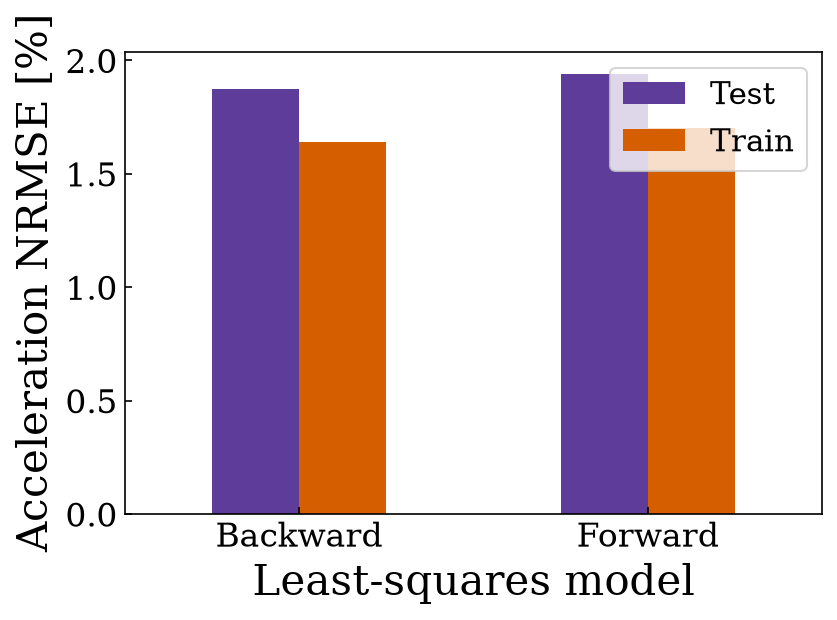

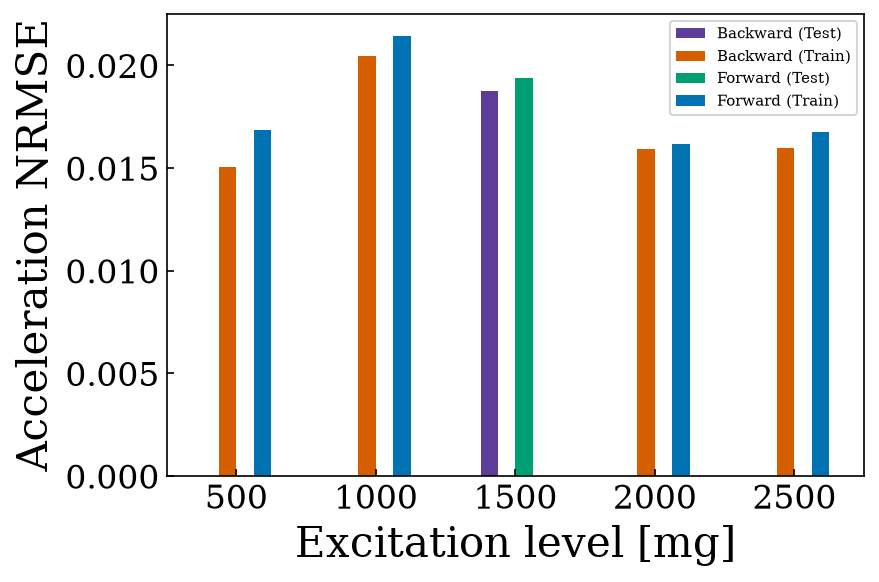

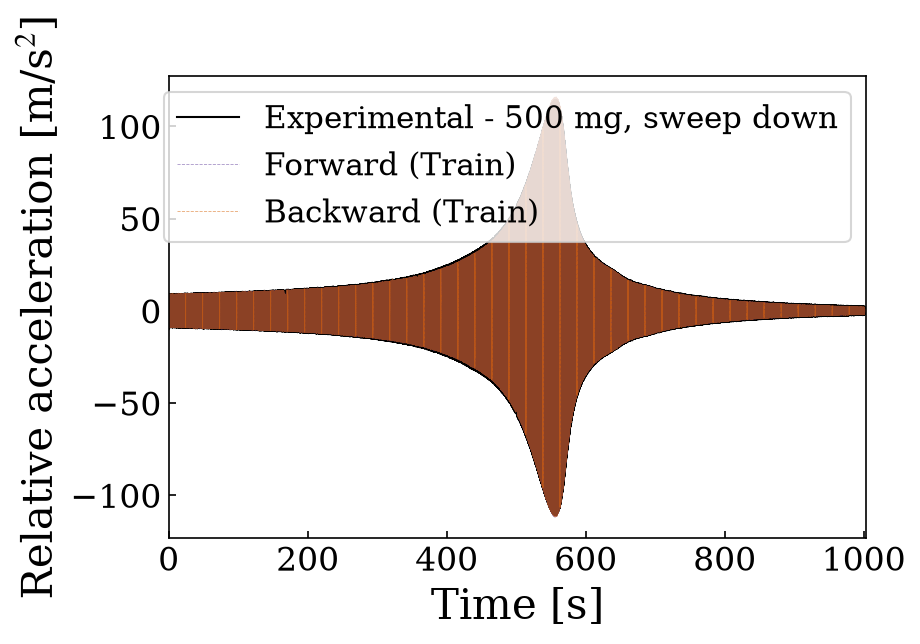

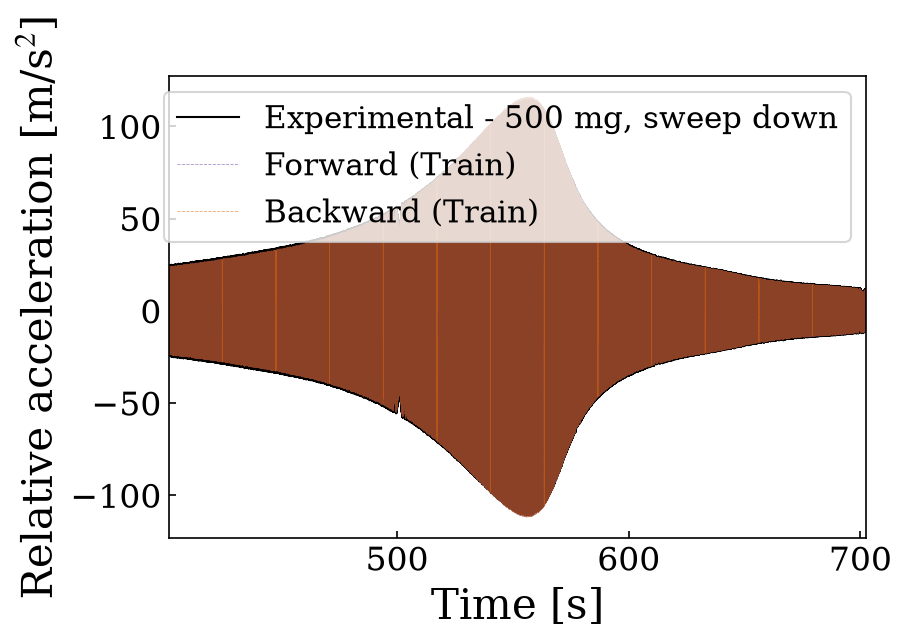

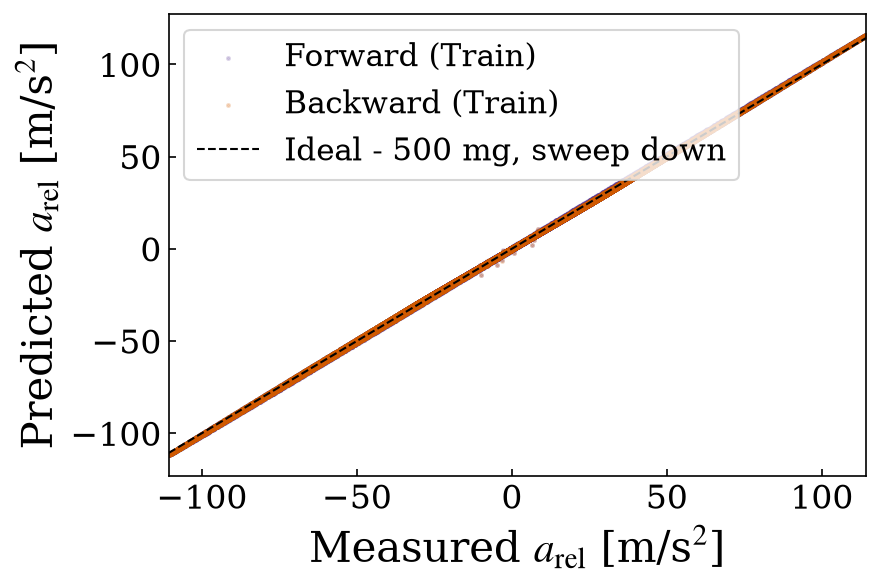

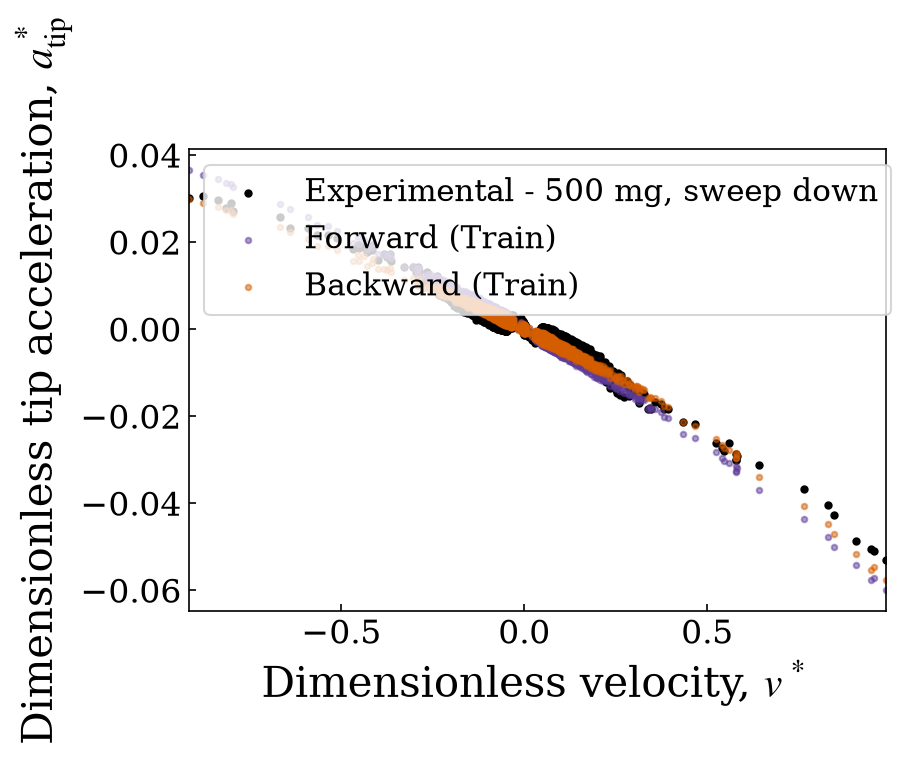

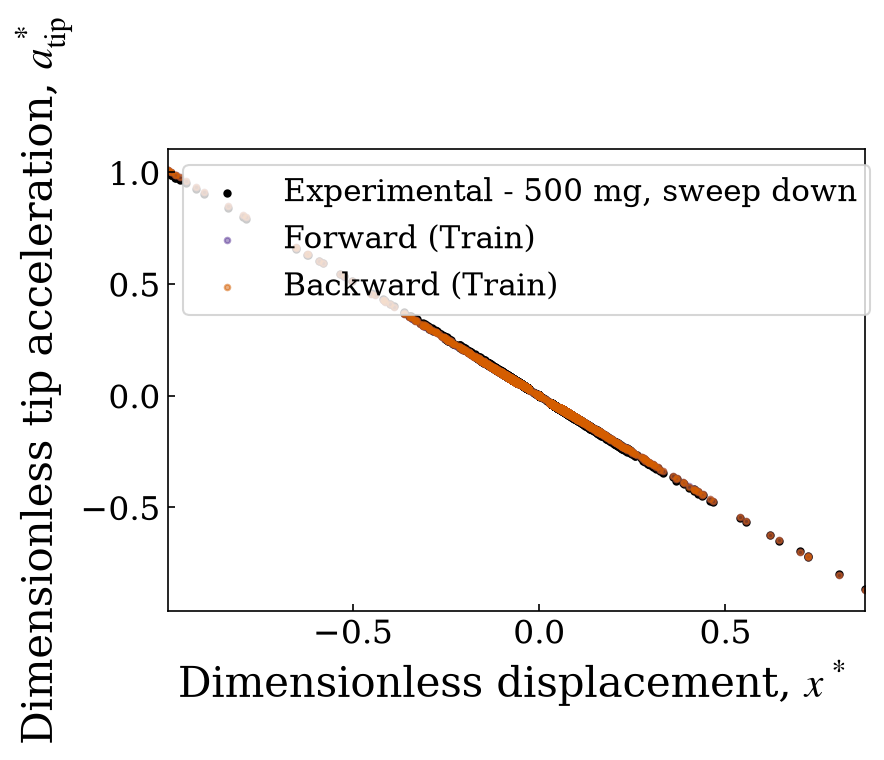

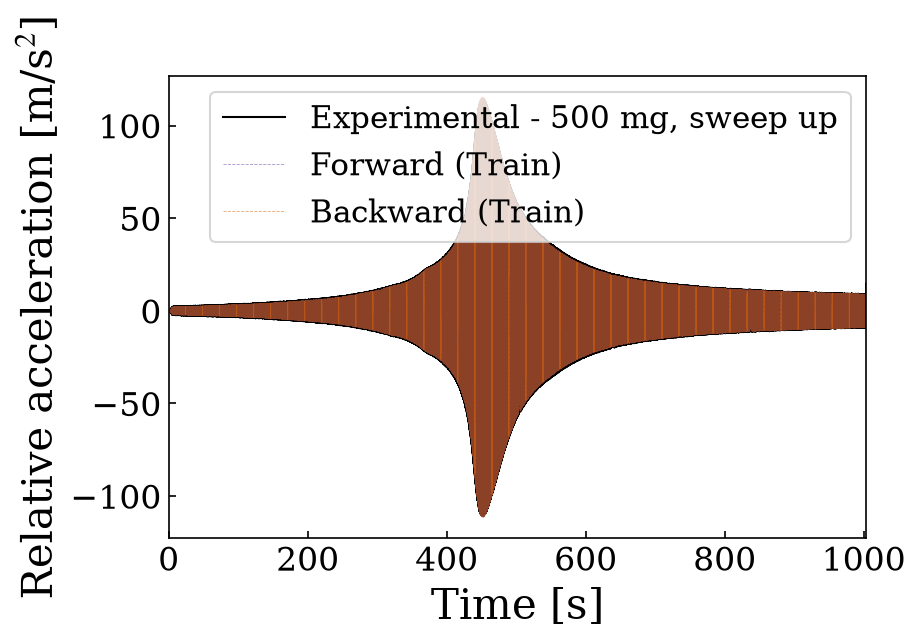

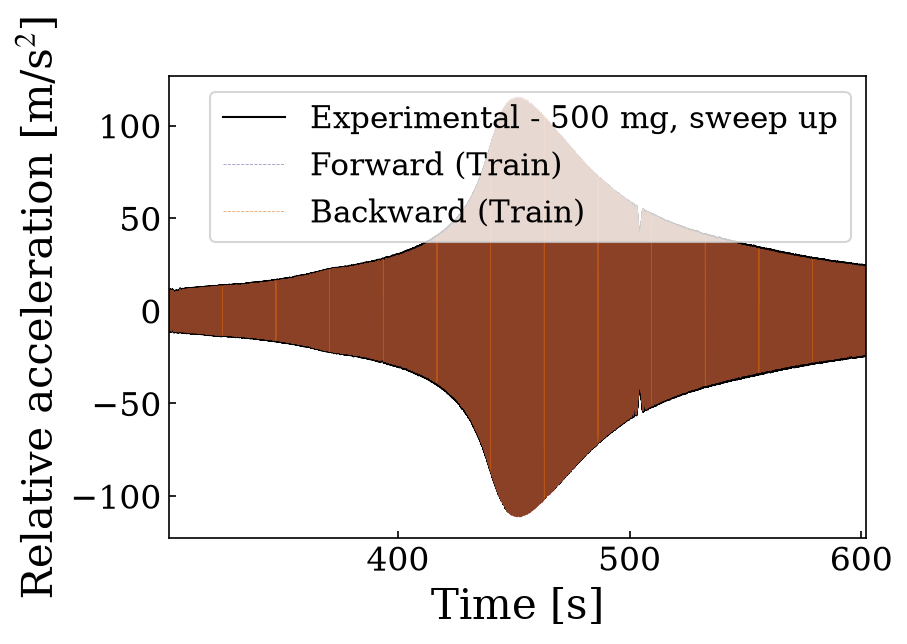

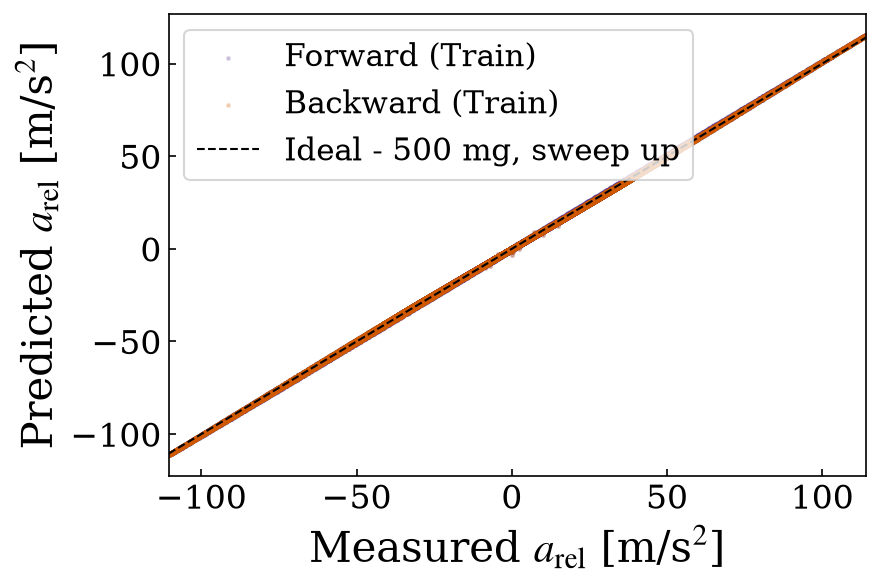

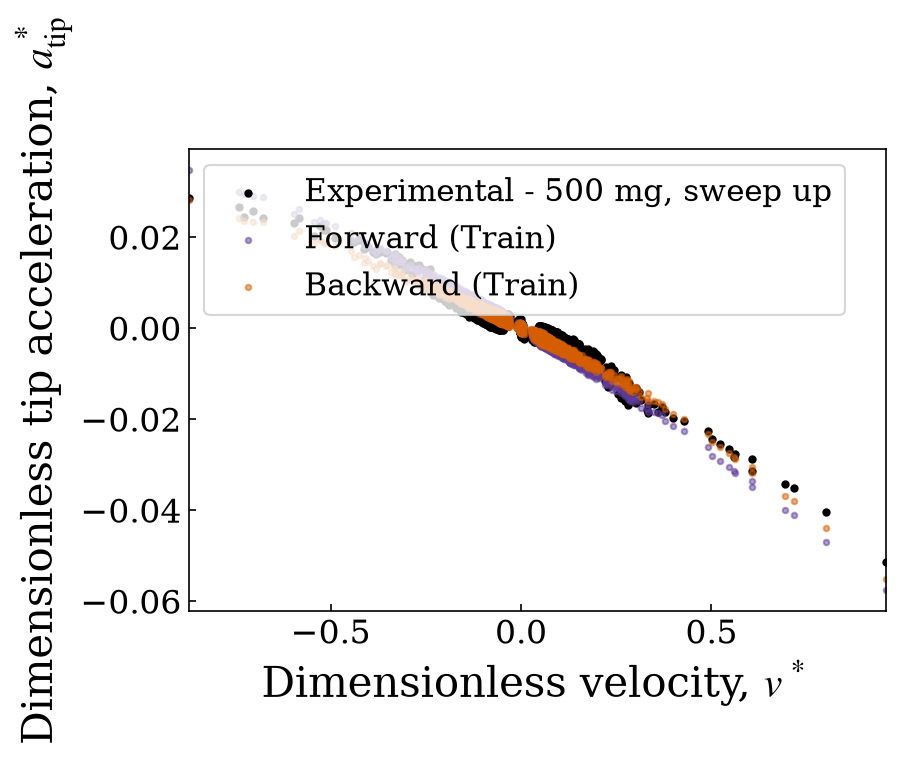

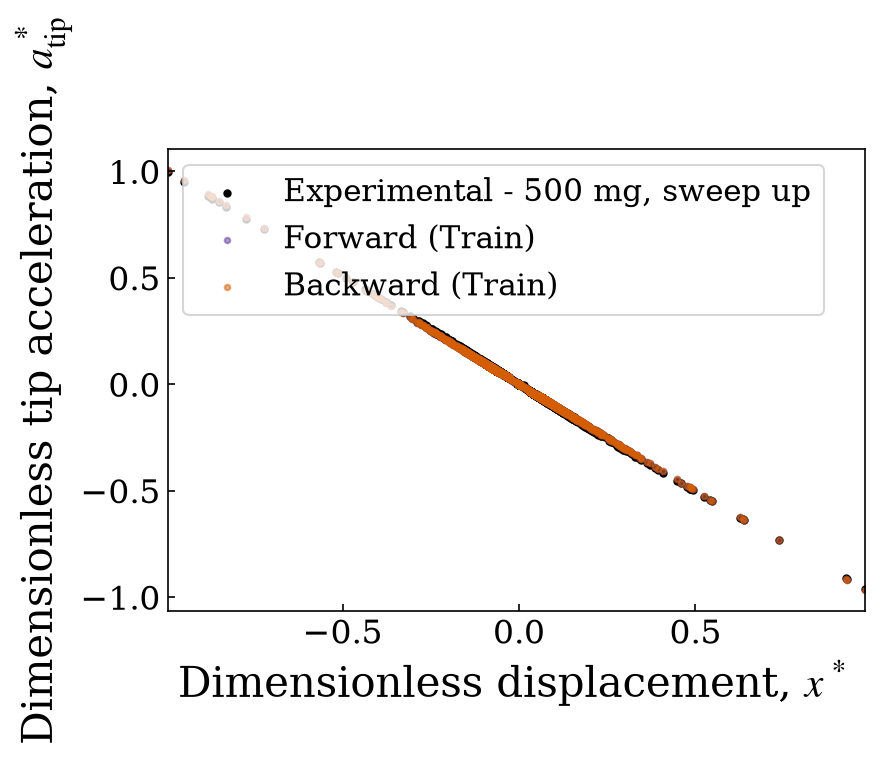

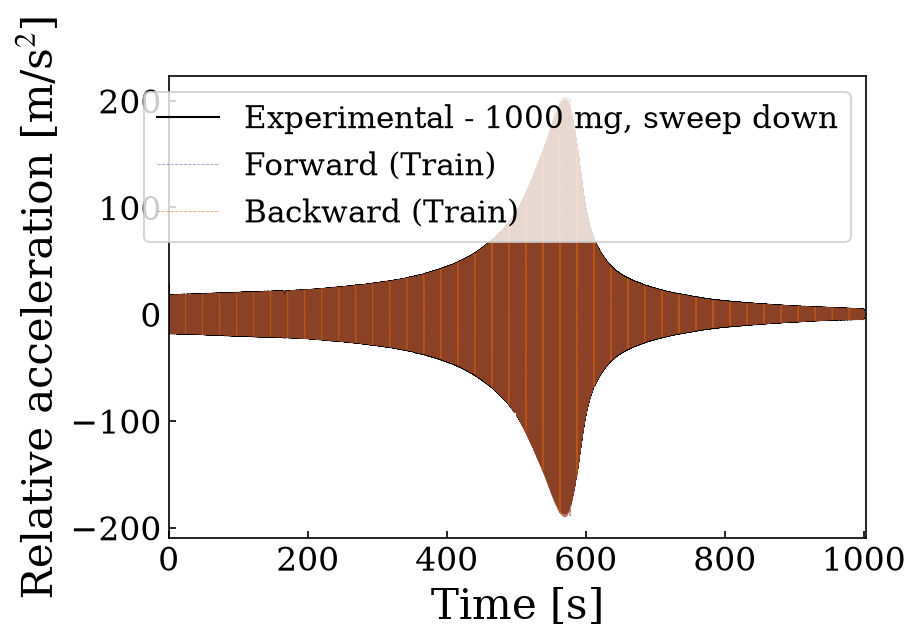

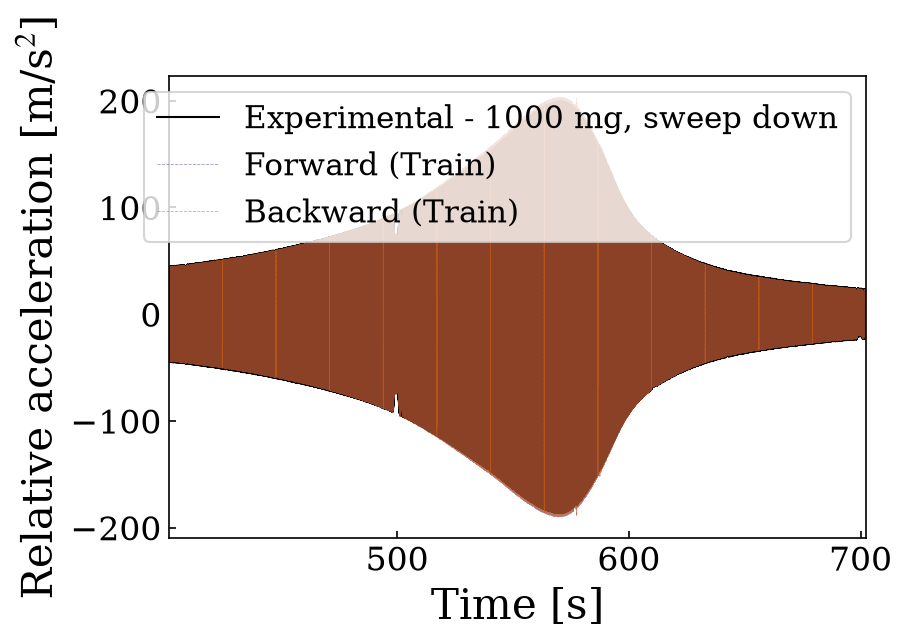

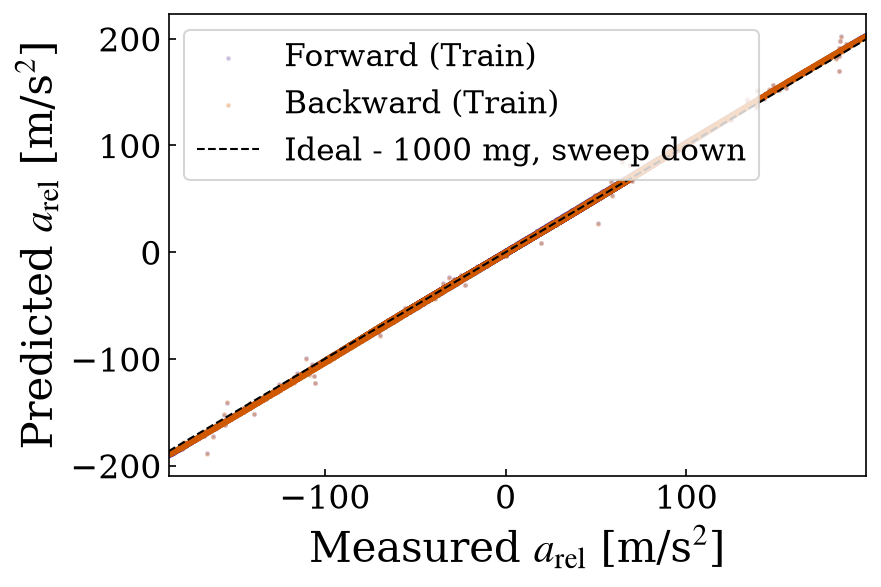

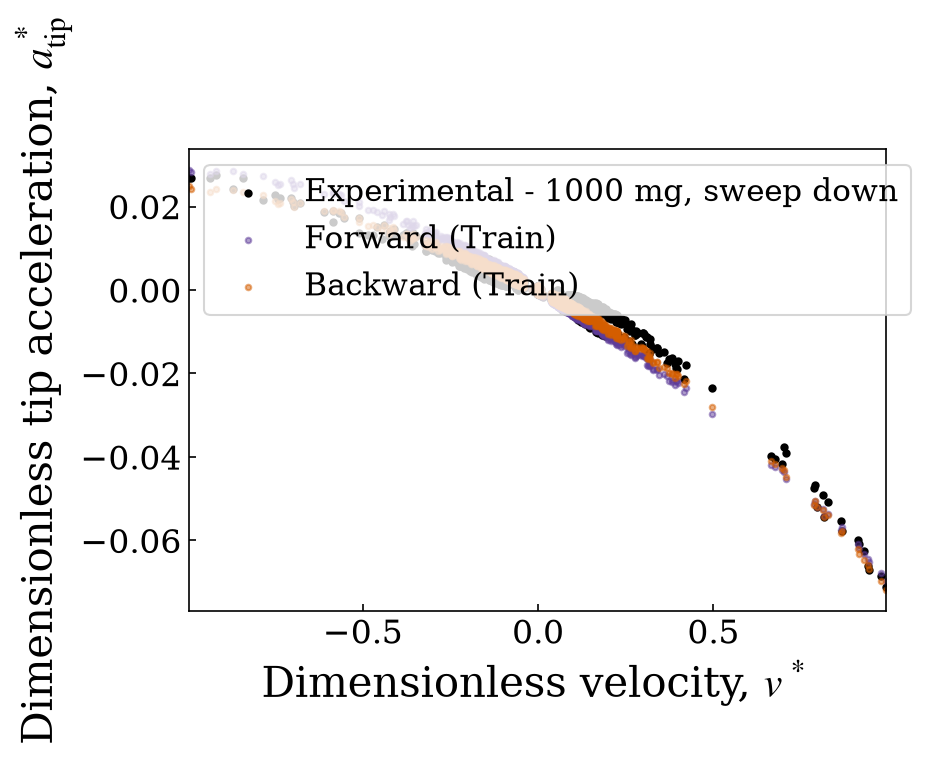

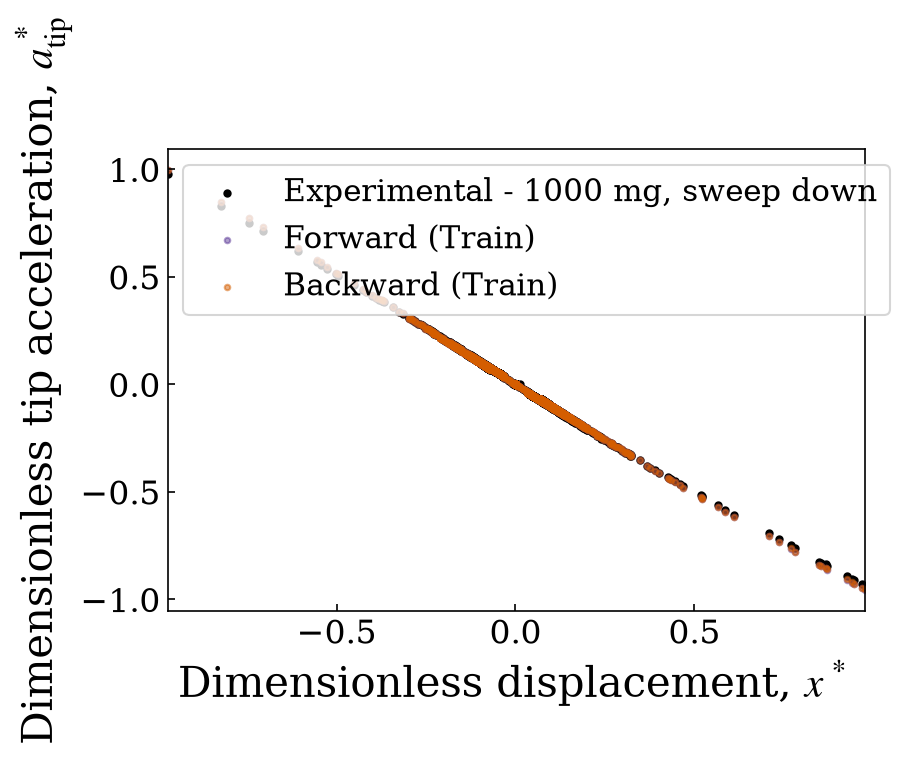

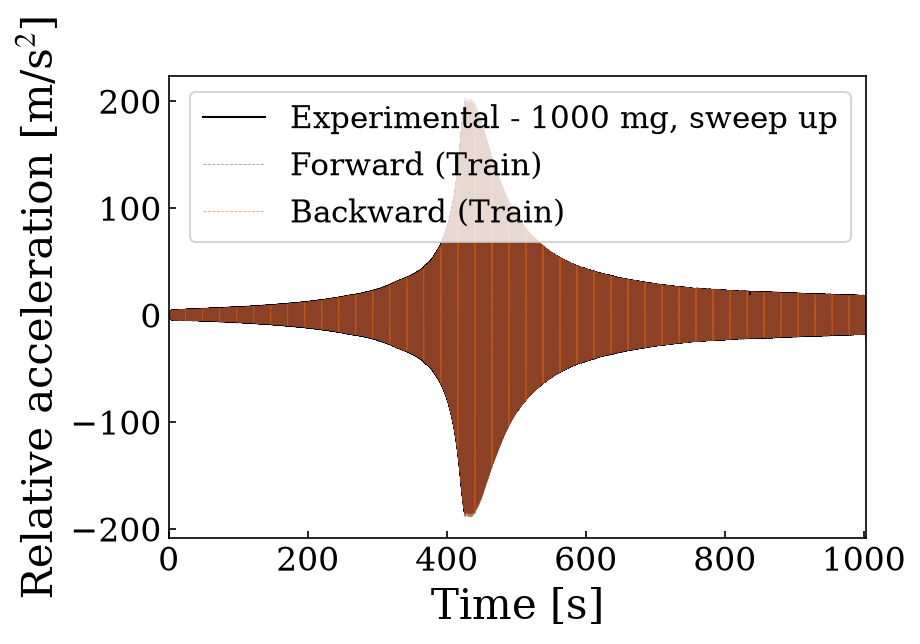

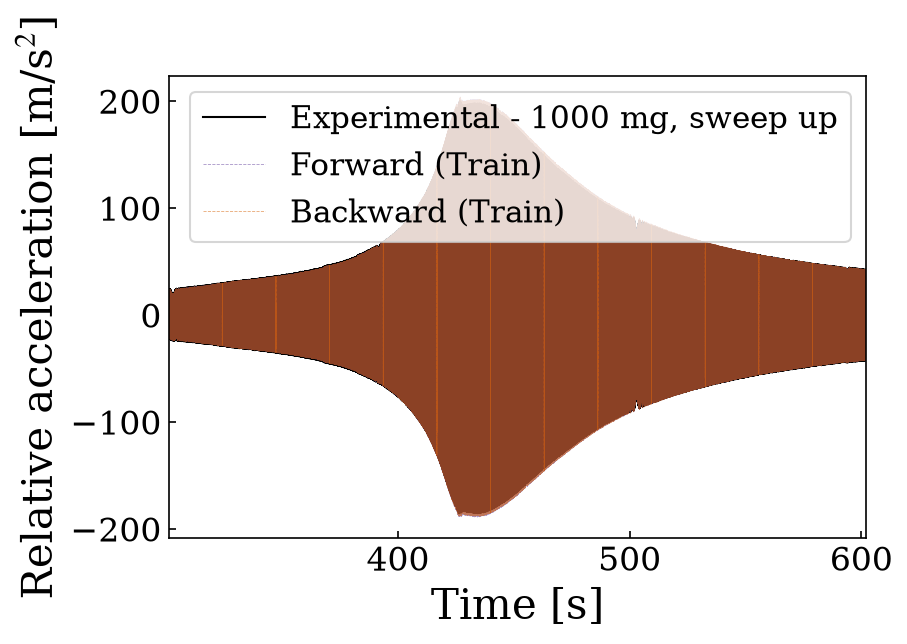

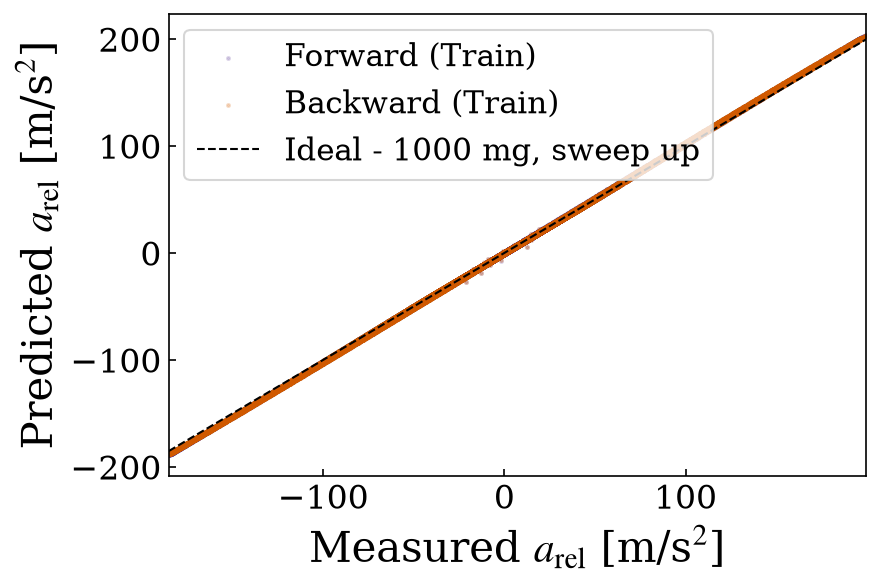

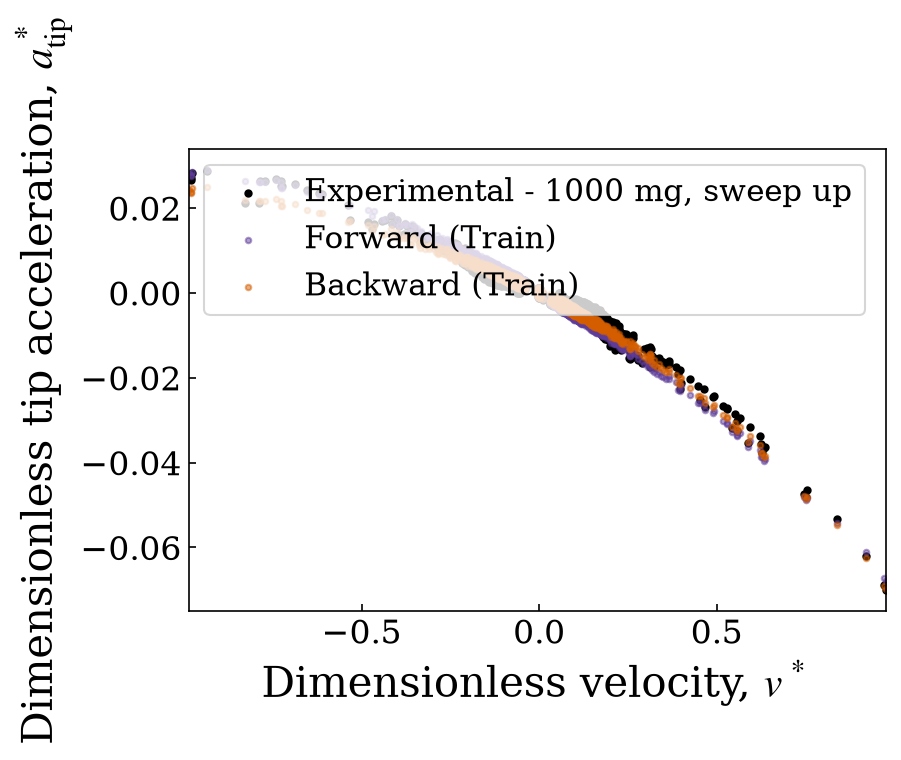

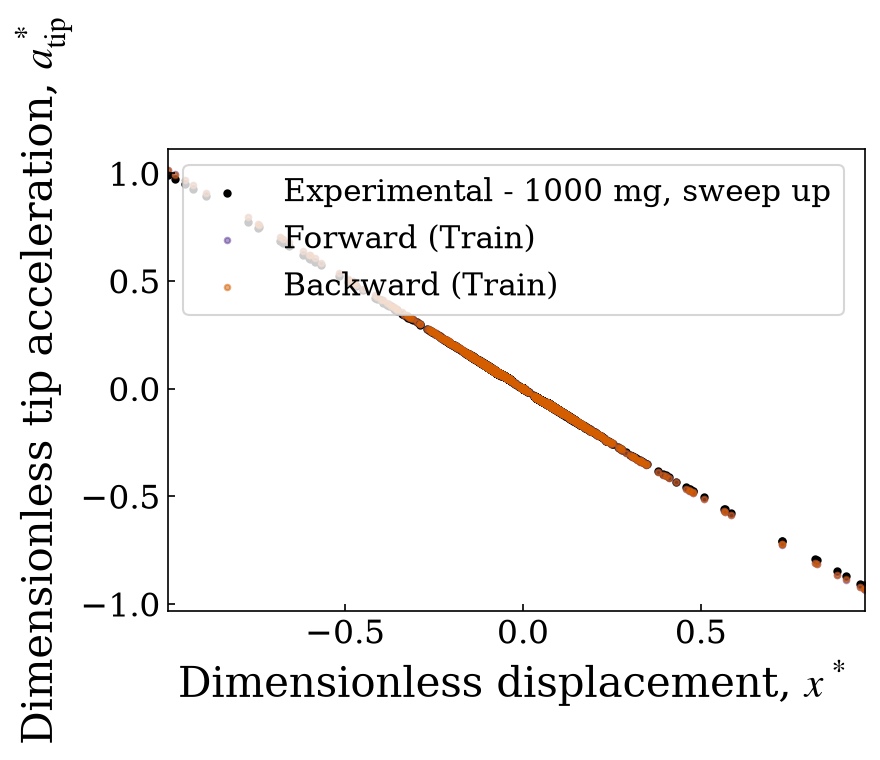

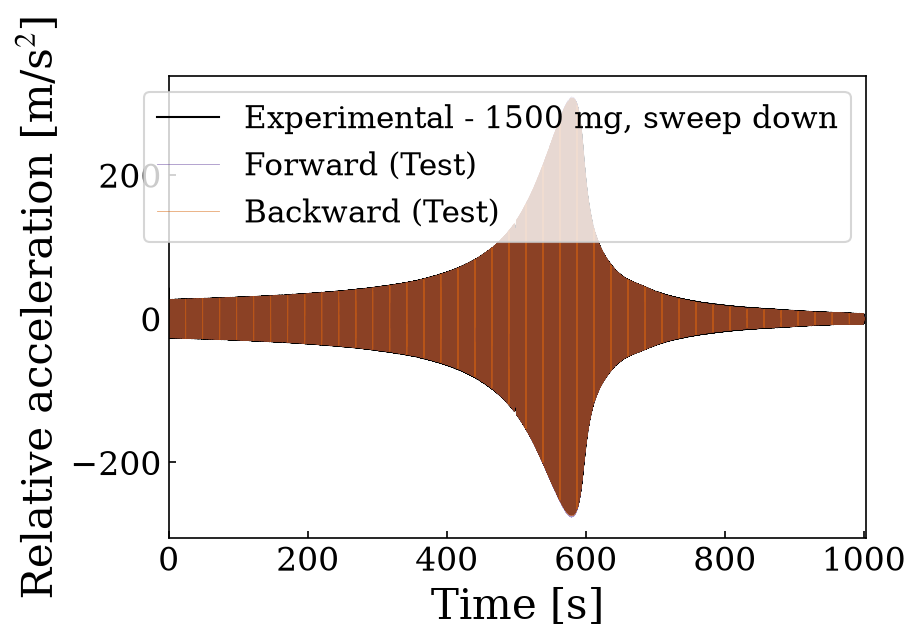

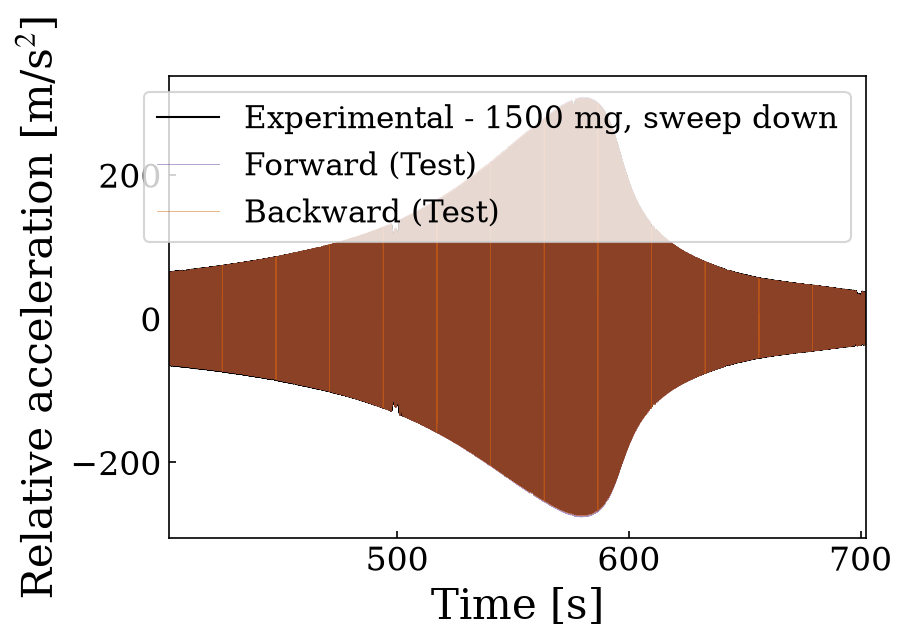

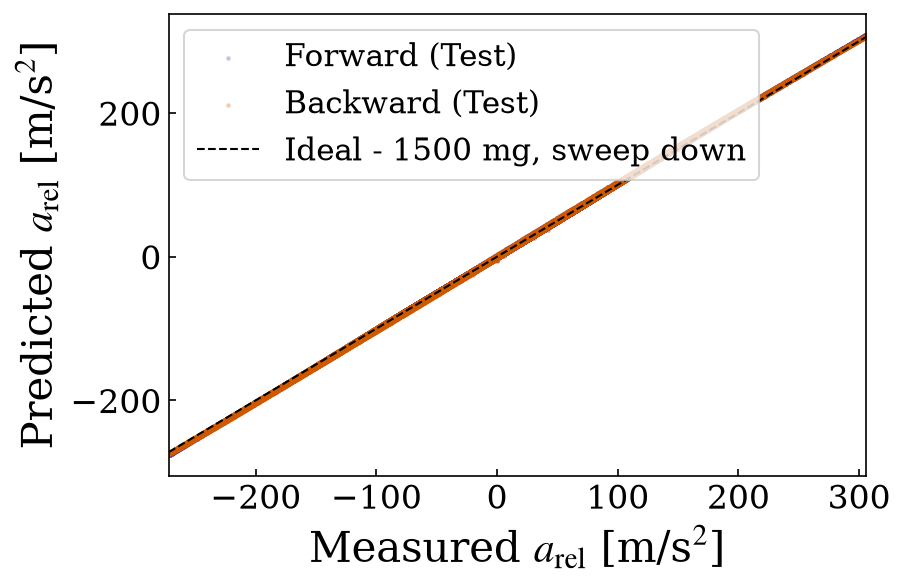

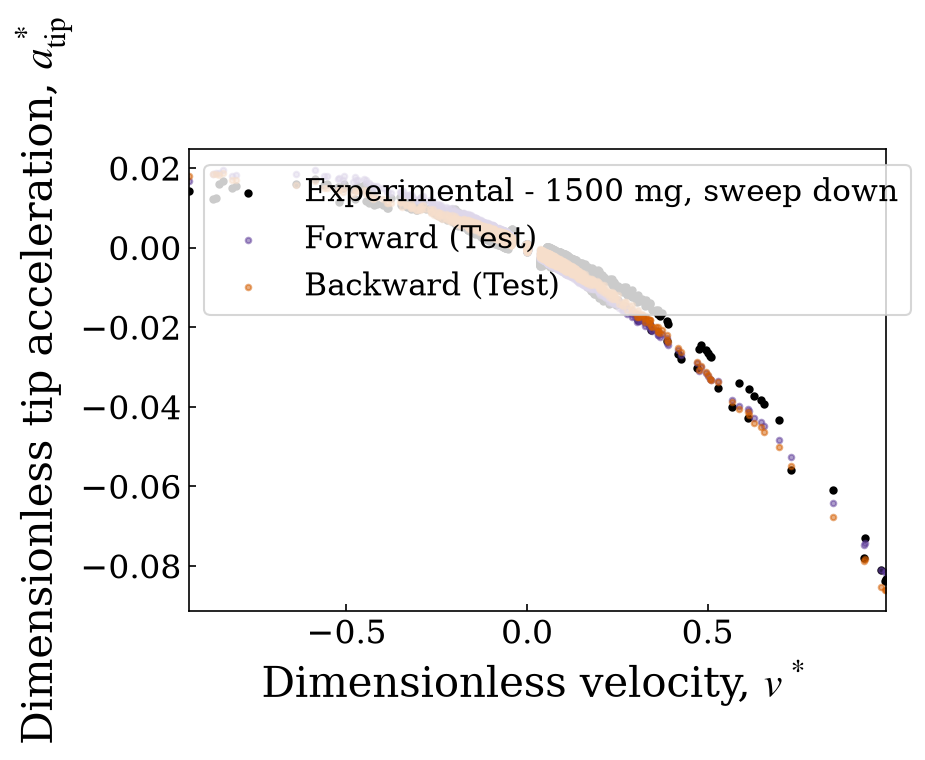

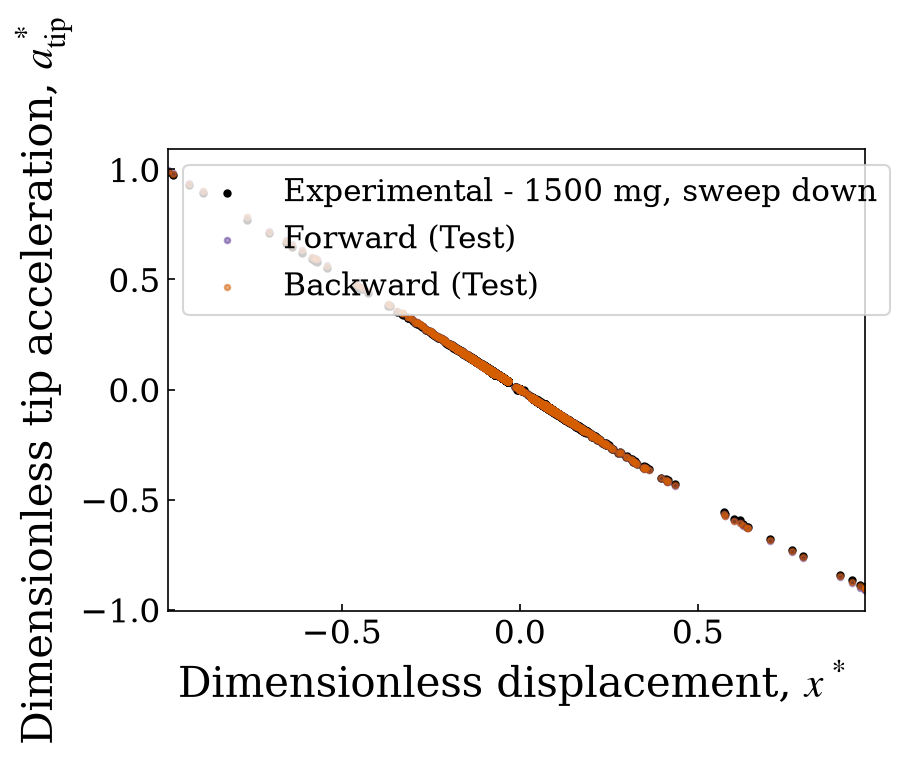

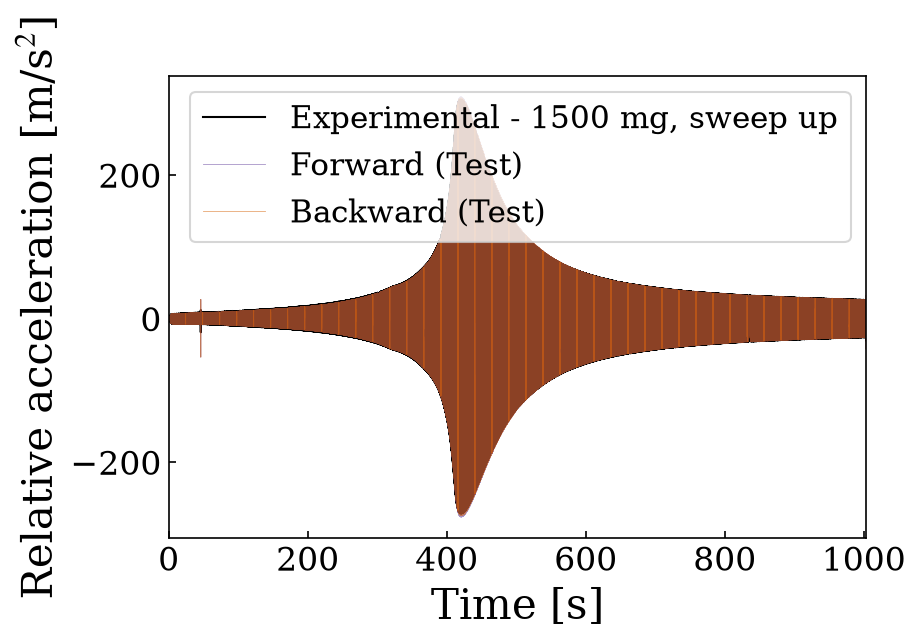

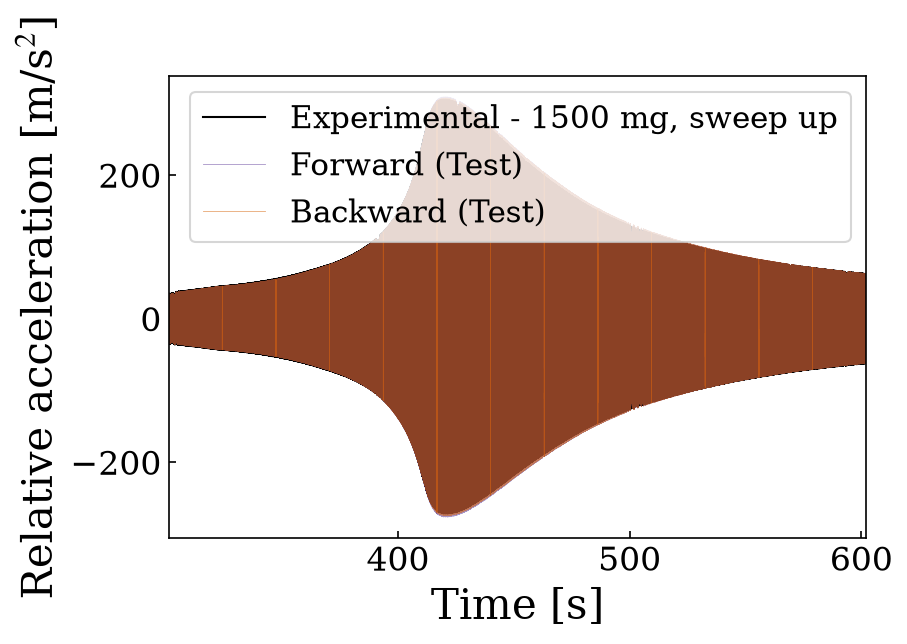

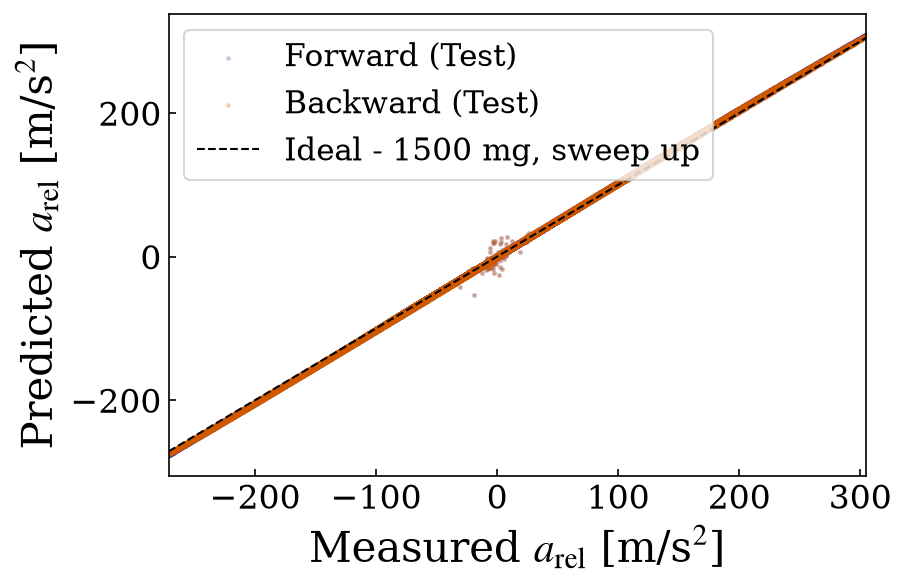

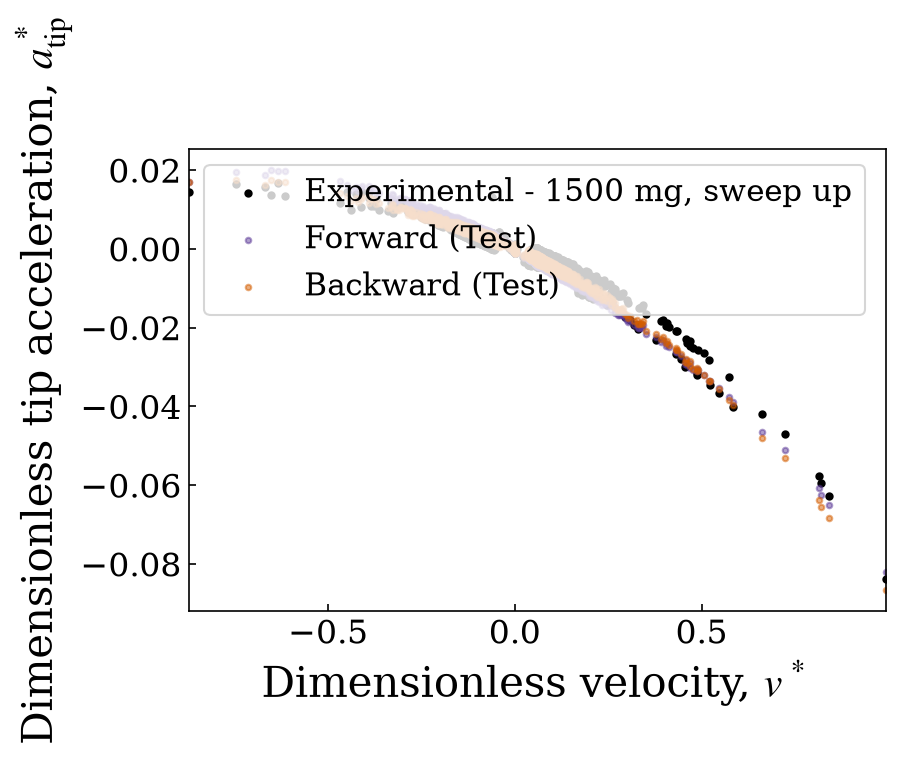

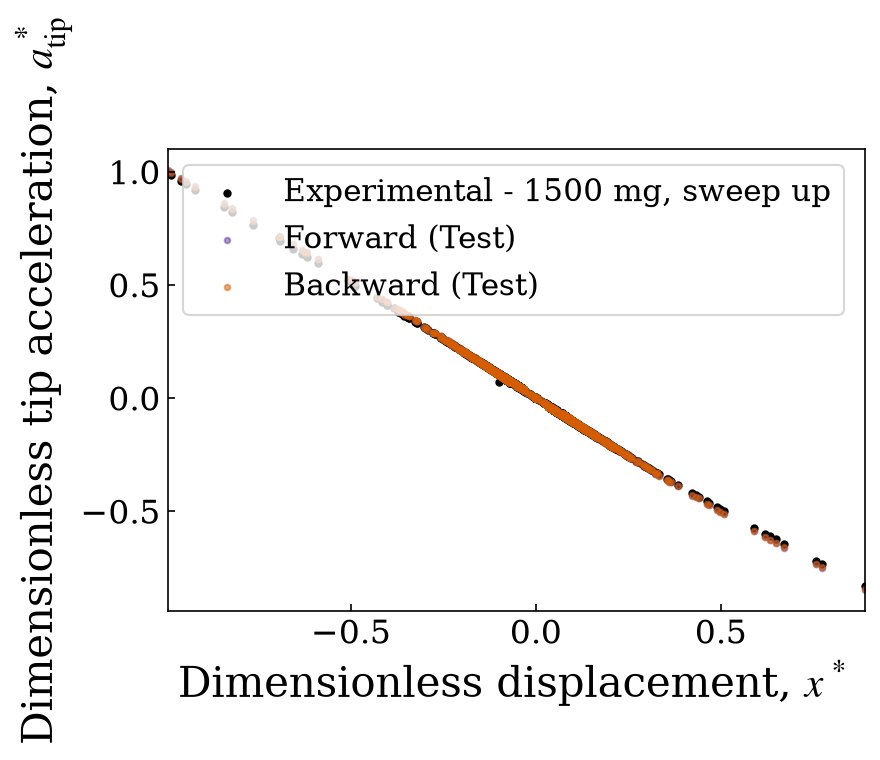

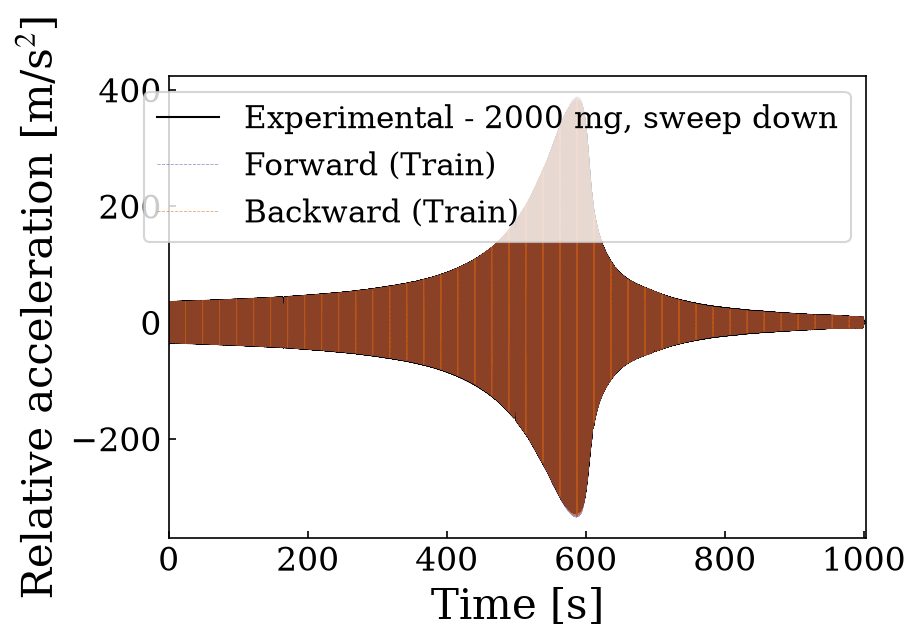

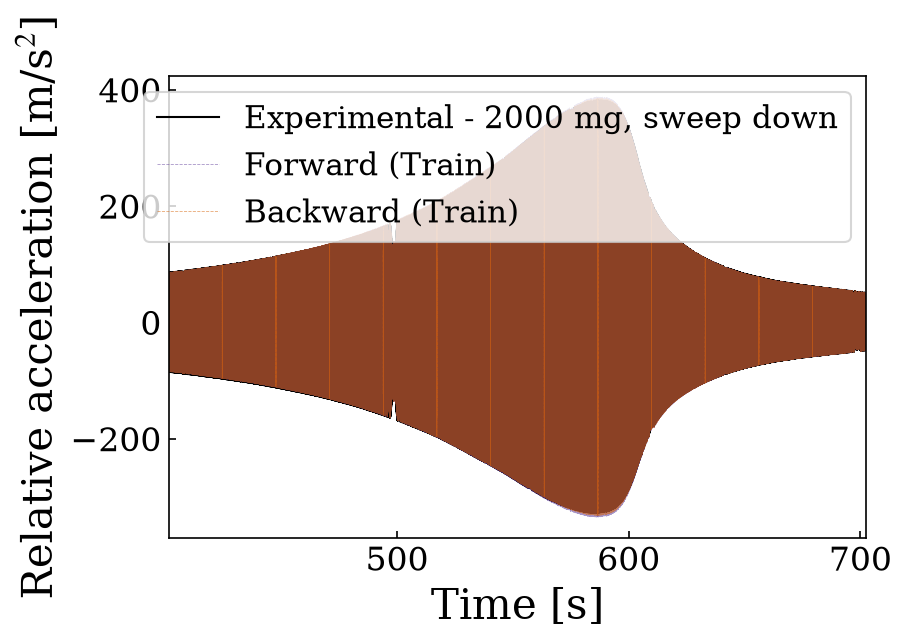

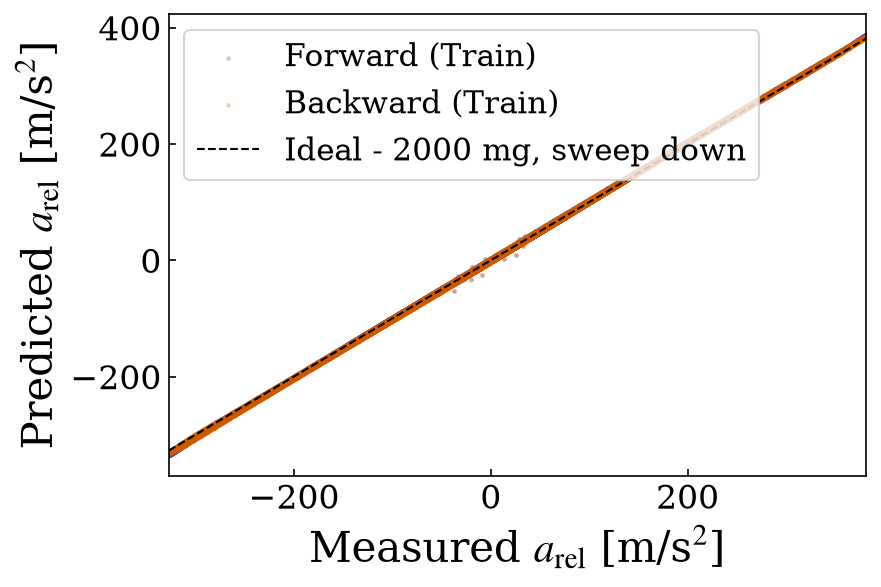

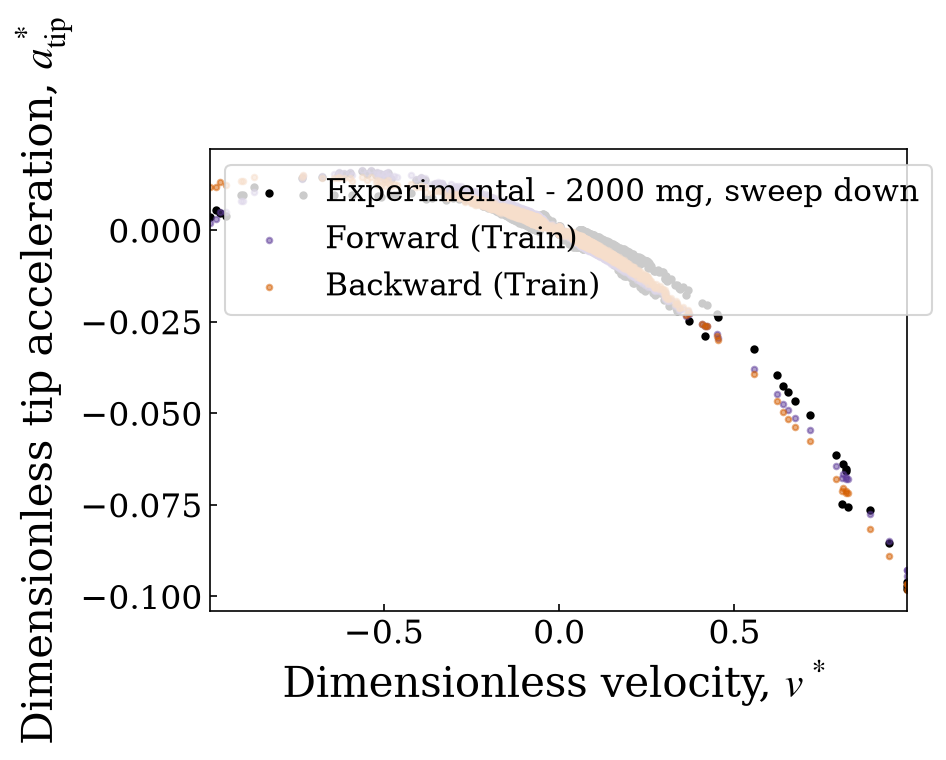

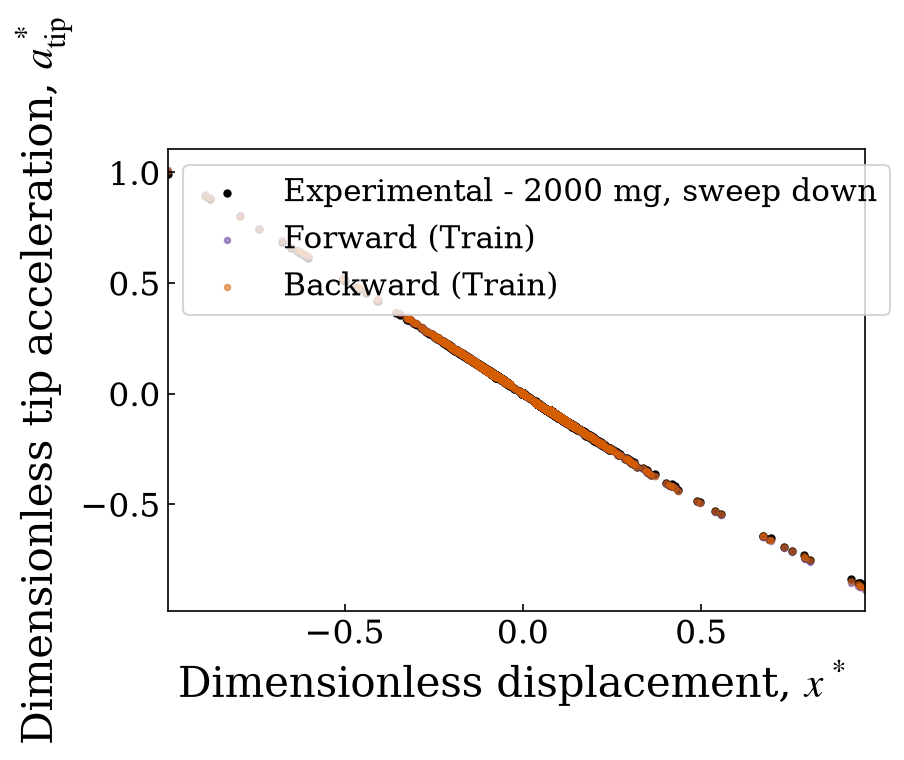

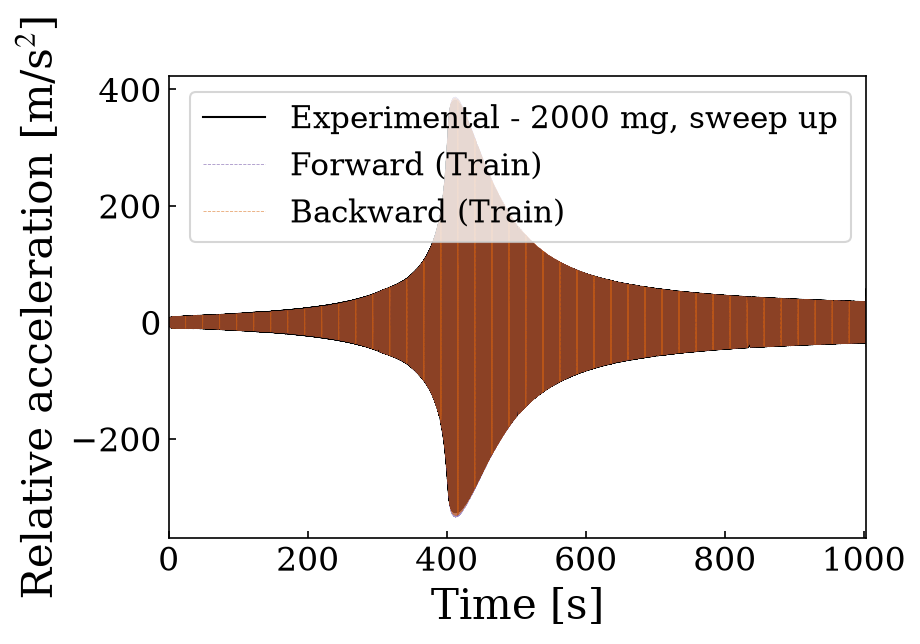

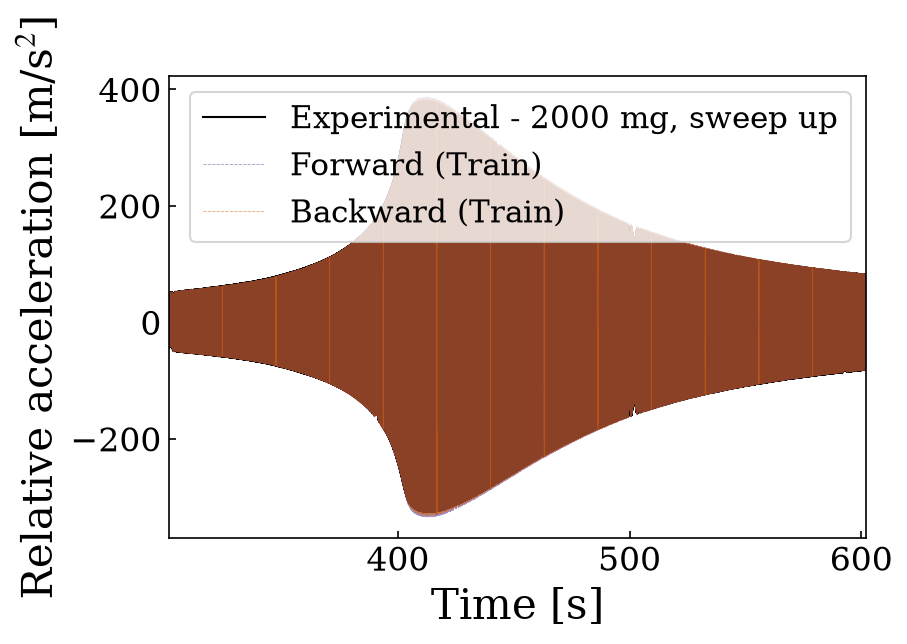

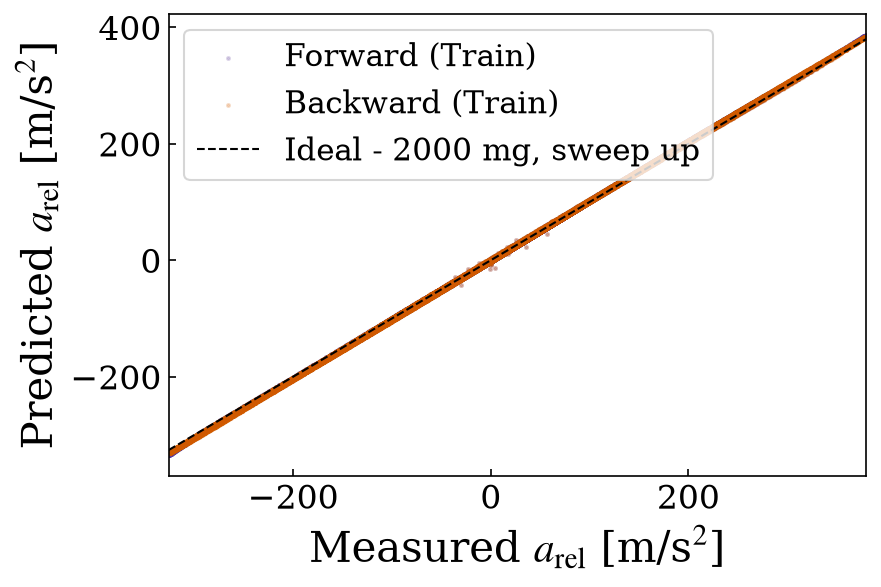

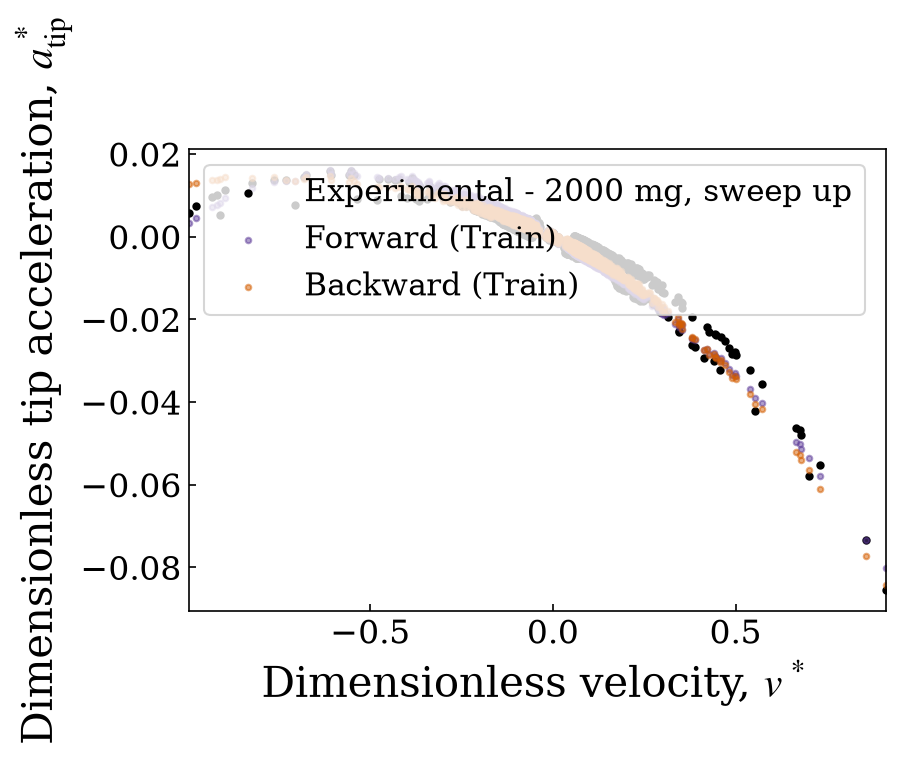

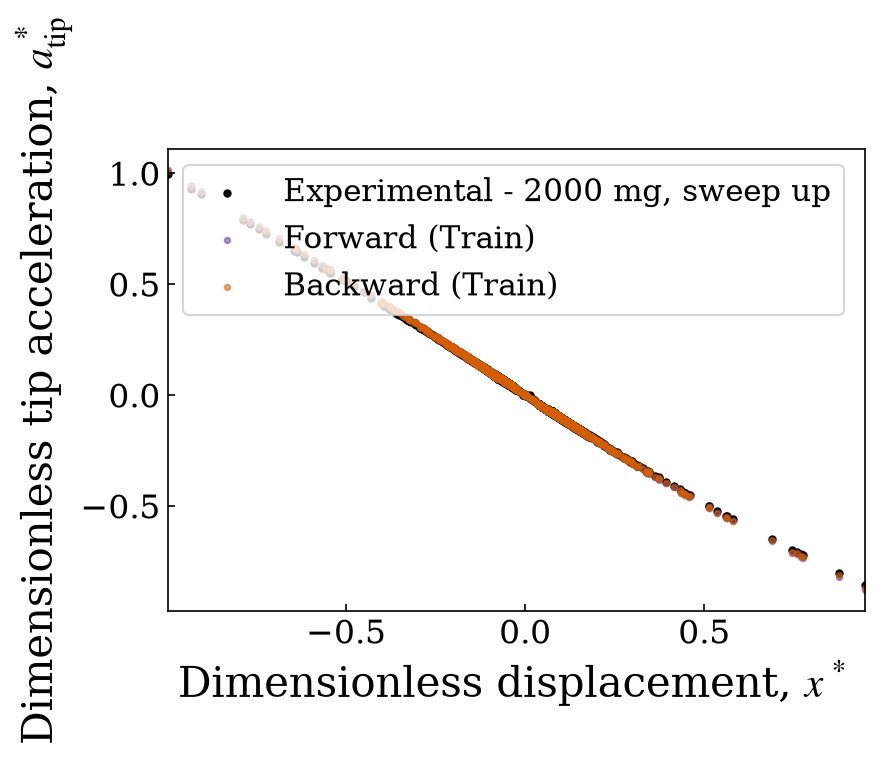

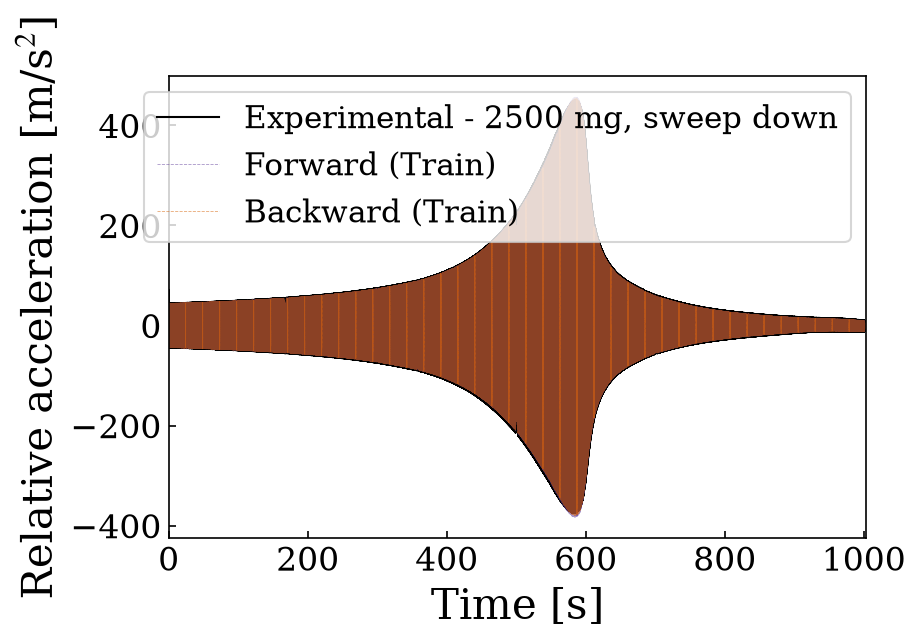

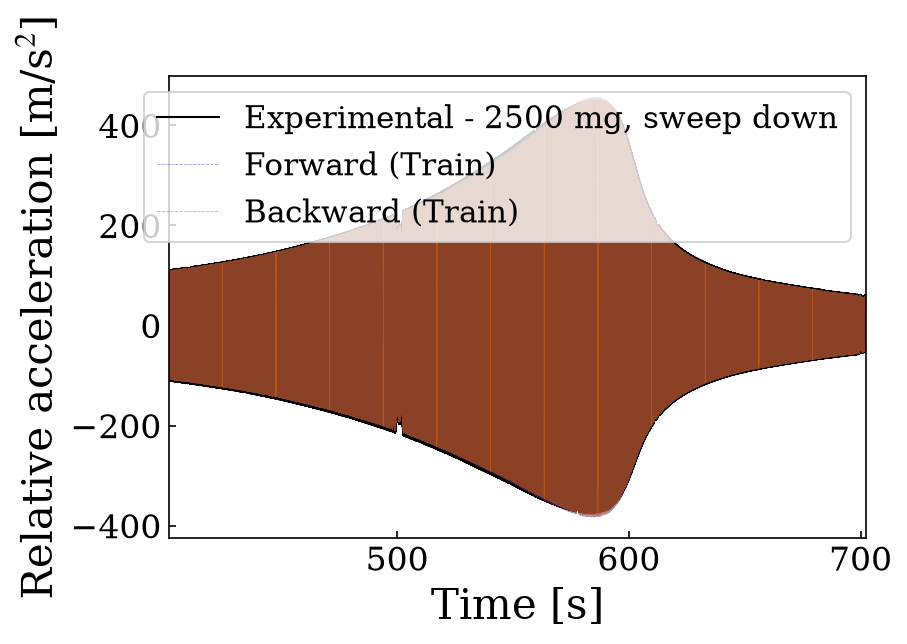

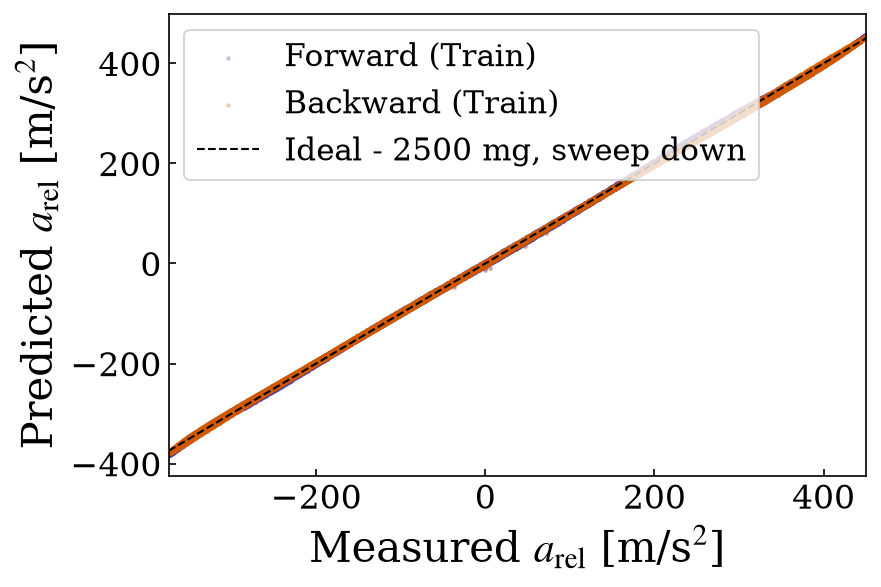

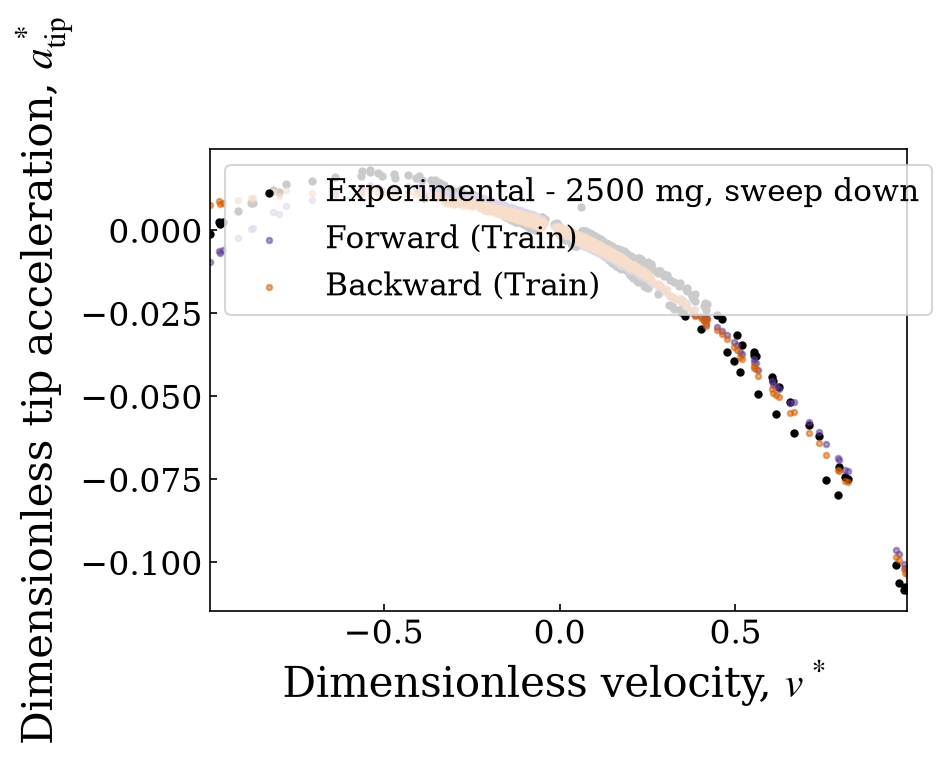

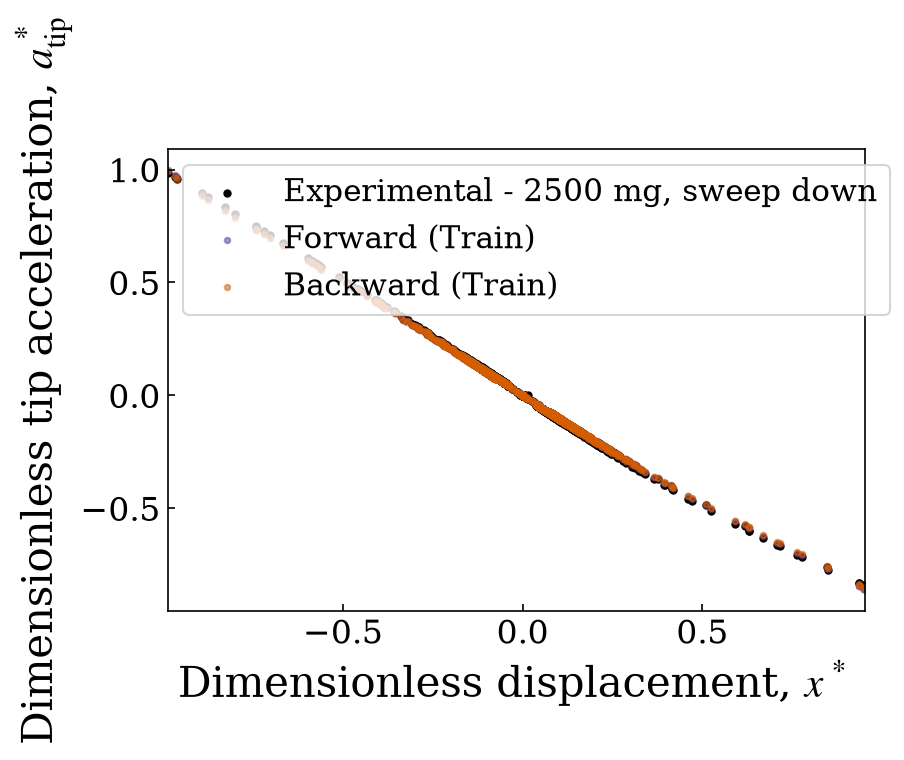

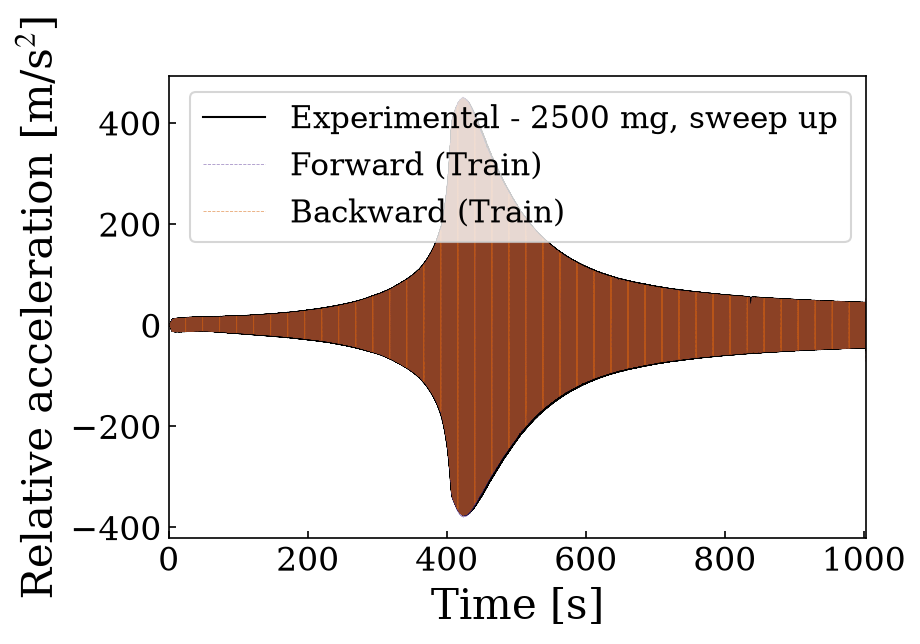

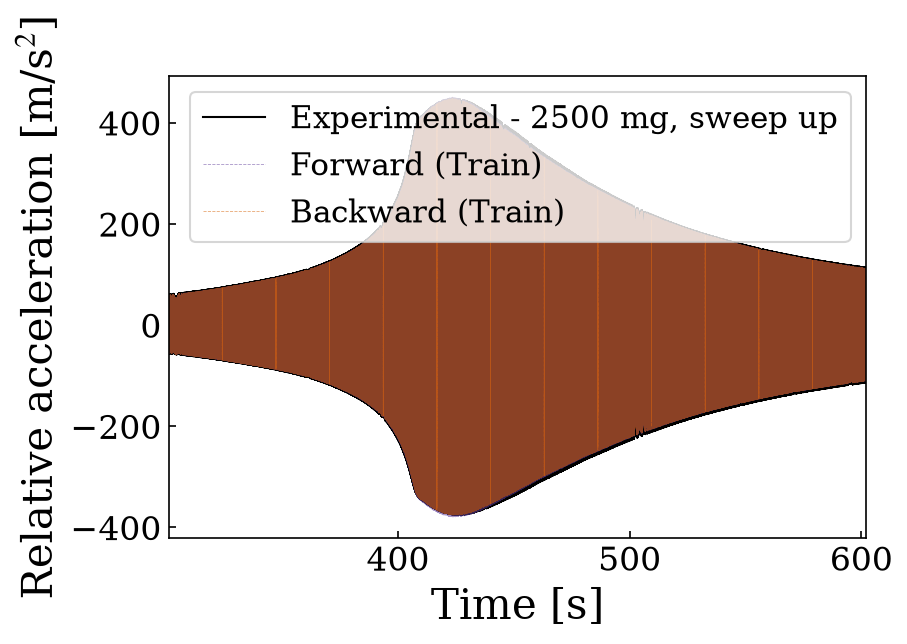

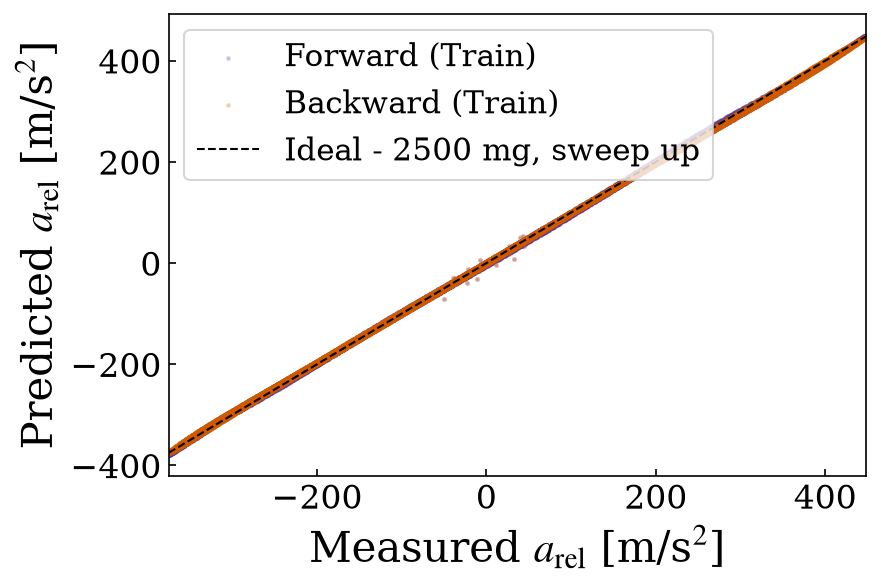

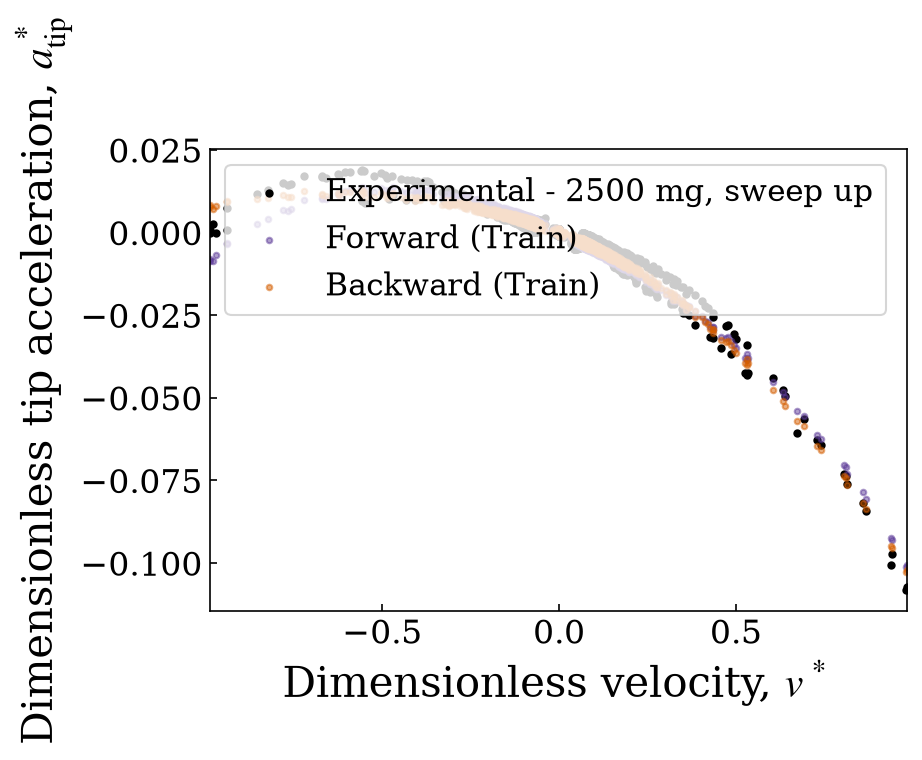

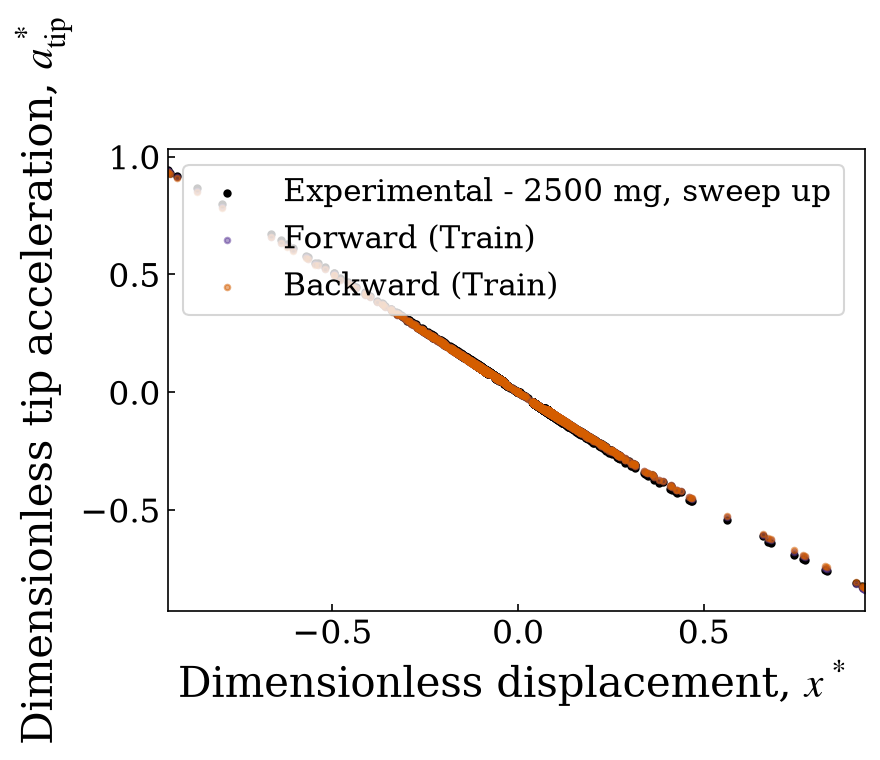

In [12]:
comparison_series = build_series(all_signals)
add_predictions(comparison_series,
                {d.capitalize(): (lambda x, v, u, theta=selection_models[d]: model_acceleration(x, v, u, theta))
                 for d in ("forward", "backward")})
split_metrics, split_per_level, split_aggregate = summarize_models(comparison_series)
display(split_metrics)
display(split_per_level)
display(split_aggregate)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots()
split_aggregate.pivot(index="model", columns="role", values="total_NRMSE").rename(columns=ROLE_LABELS).rename_axis(columns=None).mul(100).plot.bar(ax=ax)
ax.set_ylabel("Acceleration NRMSE [%]")
ax.set_xlabel("Least-squares model")
ax.tick_params(axis="x", rotation=0)
fig.savefig(FIGURES_DIR / "least_squares_selection_comparison.pdf")
plt.show()
plot_level_metrics(split_per_level, "total_NRMSE", "Acceleration NRMSE", FIGURES_DIR / "one_step_level_metrics.pdf")
dimensionless_scales = plot_diagnostics(comparison_series, FIGURES_DIR / "one_step")

## Save results


In [13]:
least_squares_results = {
    "schema_version": 9,
    "source_prepared_file": str(PREPARED_FILE.resolve()),
    "protocol": {"levels_mg": LEVELS_MG, "test_level_mg": TEST_LEVEL_MG, "training_levels_mg": TRAINING_LEVELS_MG,
                 "split": split_summary, "roles": ROLES, "description": PROTOCOL_DESCRIPTION},
    "configuration": {
        "levels_mg": LEVELS_MG, "protocol": PROTOCOL_DESCRIPTION,
        "regression_step": 1, "sweep_min_hz": SWEEP_MIN_HZ, "sweep_max_hz": SWEEP_MAX_HZ,
        "resonance_band_hz": RESONANCE_BAND_HZ,
        "total_error_weight": TOTAL_ERROR_WEIGHT, "resonance_error_weight": RESONANCE_ERROR_WEIGHT,
        "acceptable_error_increase": ACCEPTABLE_ERROR_INCREASE,
        "candidate_terms": TERM_NAMES, "max_x_power": MAX_X_POWER, "max_v_power": MAX_V_POWER,
        "polynomial_powers": POLYNOMIAL_POWERS, "all_samples_used": True,
        "dimensionless_zero_tolerance": DIMENSIONLESS_ZERO_TOLERANCE,
        "prediction_mode": "one_step_measured_state_acceleration",
        "prediction_equation": "a_hat[k] = f(x_measured[k], v_measured[k], u_measured[k])",
        "state_integration": False,
    },
    "models": {
        name: {"terms": result["terms"],
               "coefficients": {TERM_NAMES[j]: float(result["coefficients"][j]) for j in result["indices"]},
               "coefficient_vector": result["coefficients"], "training_score": result["training_score"]}
        for name, result in [("forward", selection_run["forward"]), ("backward", selection_run["backward"])]
    },
    "selection": {
        "criterion": "common criterion: fewest terms within ACCEPTABLE_ERROR_INCREASE of the best training "
                     "score (0.3 pooled NRMSE + 0.7 pooled resonance NRMSE) on the training levels",
        "relative_tolerance": ACCEPTABLE_ERROR_INCREASE,
        "run": selection_run, "summary": selection_summary,
        "coefficient_table": selection_coefficient_table,
    },
    "one_step": {"per_signal_metrics": split_metrics, "per_level": split_per_level,
                 "aggregate": split_aggregate, "series": comparison_series},
    "dimensionless_scales": dimensionless_scales,
}
results_file = RESULTS_DIR / "least_squares_selection_results.pkl"
with results_file.open("wb") as file:
    pickle.dump(least_squares_results, file, protocol=pickle.HIGHEST_PROTOCOL)
print("Saved:", results_file)

Saved: C:\Users\bruno\Downloads\BEPE (2)\BEPE\results\least_squares_selection_results.pkl


## Summary


In [ ]:
print("Protocol:", PROTOCOL_DESCRIPTION)
for name, result in [("forward", selection_run["forward"]), ("backward", selection_run["backward"])]:
    print(f"{name}: {len(result['indices'])} terms; training score = {result['training_score']:.6f}")
    print("a_rel = " + " + ".join(f"({result['coefficients'][j]:+.8e}) {TERM_NAMES[j]}" for j in result["indices"]))
display(selection_summary)
display(split_aggregate)
print("Figures:", FIGURES_DIR.resolve())
print("Results:", results_file.resolve())

Protocol: single train/test split: test level 1500 mg; training levels (500, 1000, 2000, 2500) mg
forward: 10 terms; training score = 0.016597
a_rel = (-3.61124524e+05) x + (-3.14259404e+01) v + (+1.41827405e+07) x^2 + (-3.31857053e+01) v^2 + (+4.82808171e+10) x^3 + (+7.82978774e+04) x*v^2 + (-3.05723502e+01) v^4 + (-2.07875080e+16) x^5 + (-3.94066781e+11) x^3*v^4 + (-1.06037296e+00) u
backward: 10 terms; training score = 0.016168
a_rel = (-3.61306593e+05) x + (-2.55530346e+01) v + (+1.45685126e+07) x^2 + (-4.20141218e+01) v^2 + (+5.20862952e+10) x^3 + (+7.31997810e+04) x*v^2 + (-2.20167904e+16) x^5 + (-8.91886498e+10) x^3*v^2 + (-1.61850364e+01) v|v| + (-1.06110752e+00) u


,run,direction,n_terms,terms,training_score,training_score_limit
0,"training levels (500, 1000, 2000, 2500) mg",forward,10,"x, v, x^2, v^2, x^3, x*v^2, v^4, x^5, x^3*v^4, u",0.016597,0.016611
1,"training levels (500, 1000, 2000, 2500) mg",backward,10,"x, v, x^2, v^2, x^3, x*v^2, x^5, x^3*v^2, v|v|, u",0.016168,0.016611


,model,role,levels_mg,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,Forward,train,"(500, 1000, 2000, 2500)",8,3211138,1.096832,0.017036,0.999710,0.016158,0.016597
1,Forward,test,"(1500,)",2,802753,1.137953,0.019398,0.999624,0.019082,0.019240
2,Backward,train,"(500, 1000, 2000, 2500)",8,3211138,1.056156,0.016404,0.999731,0.015932,0.016168
3,Backward,test,"(1500,)",2,802753,1.099379,0.018740,0.999649,0.018840,0.018790


Figures: C:\Users\bruno\Downloads\BEPE (2)\BEPE\figures\pipeline\3_least_squares_selection\forward_backward_one_step
Results: C:\Users\bruno\Downloads\BEPE (2)\BEPE\results\least_squares_selection_results.pkl
